# ⚡ Electricity Load Forecasting — ARIMA / SARIMA / SARIMAX Full Pipeline
**Dataset:** `continuous_dataset.csv` (2015–2020, hourly)
---
### 🎯 Forecasting Goal
| | |
|---|---|
| **Primary target** | **12-hour ahead** forecast — predict next 12 h using 24 h of history |
| **Secondary target** | **24-hour ahead** forecast — predict full next day |
| **Output strategy** | **Sequence-to-sequence** — all steps predicted simultaneously (not recursive) |
| **Horizons compared** | 12 h vs 24 h: how does accuracy degrade from 12-step to 24-step? |
| **History window** | 24 hours lookback |

---
### 📋 ML Pipeline
```
EDA ──► Preprocessing ──► Feature Engineering ──► Model Training (CV) ──► Model Testing ──► Analysis
                                                          ▲                      │
                                                          └──── Hyperparameter ◄─┘
                                                                  Tuning
```

| Step | Content |
|---|---|
| 1 | EDA — overview, seasonality, ADF stationarity, ACF/PACF |
| 2 | Data Preprocessing |
| 3 | Feature Engineering (lag, cyclical, rolling, differencing) |
| 4 | 5-Fold Year-Based Expanding Window CV |
| 5 | Model Justification — ARIMA vs SARIMA vs SARIMAX |
| 6 | Hyperparameter Grid Search (SARIMA configurations) |
| 7 | Model Training — ARIMA / SARIMA / SARIMAX across all CV folds |
| 8 | Model Evaluation — cross-fold MAE / RMSE / MAPE |
| 9 | Multi-Horizon Seq2Seq Evaluation (**12 h** and **24 h** ahead) |
| 10 | Exogenous Variable Analysis (all folds) |
| 11 | Robustness + Wilcoxon Test |
| 12 | Overfitting Analysis (train vs validation behaviour) |
| 13 | Error Analysis + Feature Importance (SHAP) |
| 💾 | Save All Plots to Google Drive |


## 🔧 Setup

In [1]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from itertools import product
from scipy.stats import wilcoxon

from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.ensemble import RandomForestRegressor
from matplotlib.patches import Patch
import shap

plt.rcParams.update({'figure.dpi': 110, 'font.size': 11})
SEED = 42
np.random.seed(SEED)

# ── Forecast constants ────────────────────────────────────────────────────────
HORIZON_12    = 12     # primary:   12-hour ahead forecast (seq2seq)
HORIZON_24    = 24     # secondary: 24-hour ahead forecast (seq2seq)
HISTORY_HOURS = 24     # lookback window used to condition each forecast
STEP_HOURS    = 1      # each step = 1 hour (hourly data)

print(f'✅ All imports OK')
print(f'   Primary   : {HORIZON_12}-step seq2seq  ({HORIZON_12*STEP_HOURS}h ahead)')
print(f'   Secondary : {HORIZON_24}-step seq2seq  ({HORIZON_24*STEP_HOURS}h ahead)')
print(f'   History   : {HISTORY_HOURS}h lookback')

✅ All imports OK
   Primary   : 12-step seq2seq  (12h ahead)
   Secondary : 24-step seq2seq  (24h ahead)
   History   : 24h lookback


## 📂 Load Dataset

In [2]:
from google.colab import files
uploaded  = files.upload()
DATA_PATH = list(uploaded.keys())[0]
print(f'✅ Uploaded: {DATA_PATH}')

Saving continuous dataset.csv to continuous dataset.csv
✅ Uploaded: continuous dataset.csv


In [3]:
df = pd.read_csv(DATA_PATH, parse_dates=['datetime'])
df = df.sort_values('datetime').reset_index(drop=True)
print(f'Shape      : {df.shape}')
print(f'Date range : {df.datetime.min()}  →  {df.datetime.max()}')
print(f'Columns    : {df.columns.tolist()}')
df.head(3)

Shape      : (48048, 17)
Date range : 2015-01-03 01:00:00  →  2020-06-27 00:00:00
Columns    : ['datetime', 'nat_demand', 'T2M_toc', 'QV2M_toc', 'TQL_toc', 'W2M_toc', 'T2M_san', 'QV2M_san', 'TQL_san', 'W2M_san', 'T2M_dav', 'QV2M_dav', 'TQL_dav', 'W2M_dav', 'Holiday_ID', 'holiday', 'school']


,datetime,nat_demand,T2M_toc,QV2M_toc,TQL_toc,W2M_toc,T2M_san,QV2M_san,TQL_san,W2M_san,T2M_dav,QV2M_dav,TQL_dav,W2M_dav,Holiday_ID,holiday,school
0,2015-01-03 01:00:00,970.3450,25.865259,0.018576,0.016174,21.850546,23.482446,0.017272,0.001855,10.328949,22.662134,0.016562,0.096100,5.364148,0,0,0
1,2015-01-03 02:00:00,912.1755,25.899255,0.018653,0.016418,22.166944,23.399255,0.017265,0.001327,10.681517,22.578943,0.016509,0.087646,5.572471,0,0,0
2,2015-01-03 03:00:00,900.2688,25.937280,0.018768,0.015480,22.454911,23.343530,0.017211,0.001428,10.874924,22.531030,0.016479,0.078735,5.871184,0,0,0


## Step 1: EDA — Exploratory Data Analysis

In [4]:
# ── 1a. Basic stats + missing values ─────────────────────────────────────────
display(df.describe().round(3))
missing = df.isnull().sum()
print('\nMissing values per column:')
print(missing[missing > 0] if missing.any() else 'None ✅')

,datetime,nat_demand,T2M_toc,QV2M_toc,TQL_toc,W2M_toc,T2M_san,QV2M_san,TQL_san,W2M_san,T2M_dav,QV2M_dav,TQL_dav,W2M_dav,Holiday_ID,holiday,school
count,48048,48048.000,48048.000,48048.000,48048.000,48048.000,48048.000,48048.000,48048.000,48048.000,48048.000,48048.000,48048.000,48048.000,48048.000,48048.000,48048.000
mean,2017-09-30 00:30:00,1182.869,27.399,0.018,0.080,13.391,26.921,0.018,0.106,7.047,24.720,0.017,0.145,3.568,0.705,0.063,0.728
min,2015-01-03 01:00:00,85.193,22.953,0.012,0.000,0.009,19.765,0.010,0.000,0.060,19.934,0.010,0.000,0.015,0.000,0.000,0.000
25%,2016-05-17 12:45:00,1020.057,26.160,0.017,0.026,7.545,24.769,0.017,0.037,3.955,22.955,0.016,0.076,2.299,0.000,0.000,0.000
50%,2017-09-30 00:30:00,1168.428,27.118,0.019,0.065,12.182,26.167,0.018,0.086,5.993,24.002,0.017,0.130,3.414,0.000,0.000,1.000
75%,2019-02-12 12:15:00,1327.564,28.558,0.020,0.117,18.661,28.712,0.019,0.157,9.410,26.243,0.018,0.200,4.671,0.000,0.000,1.000
max,2020-06-27 00:00:00,1754.882,35.040,0.023,0.521,39.230,39.063,0.022,0.485,24.484,34.216,0.021,0.478,10.289,22.000,1.000,1.000
std,NaN,192.069,1.675,0.002,0.066,7.296,3.018,0.002,0.086,4.104,2.414,0.002,0.088,1.711,3.147,0.243,0.445



Missing values per column:
None ✅


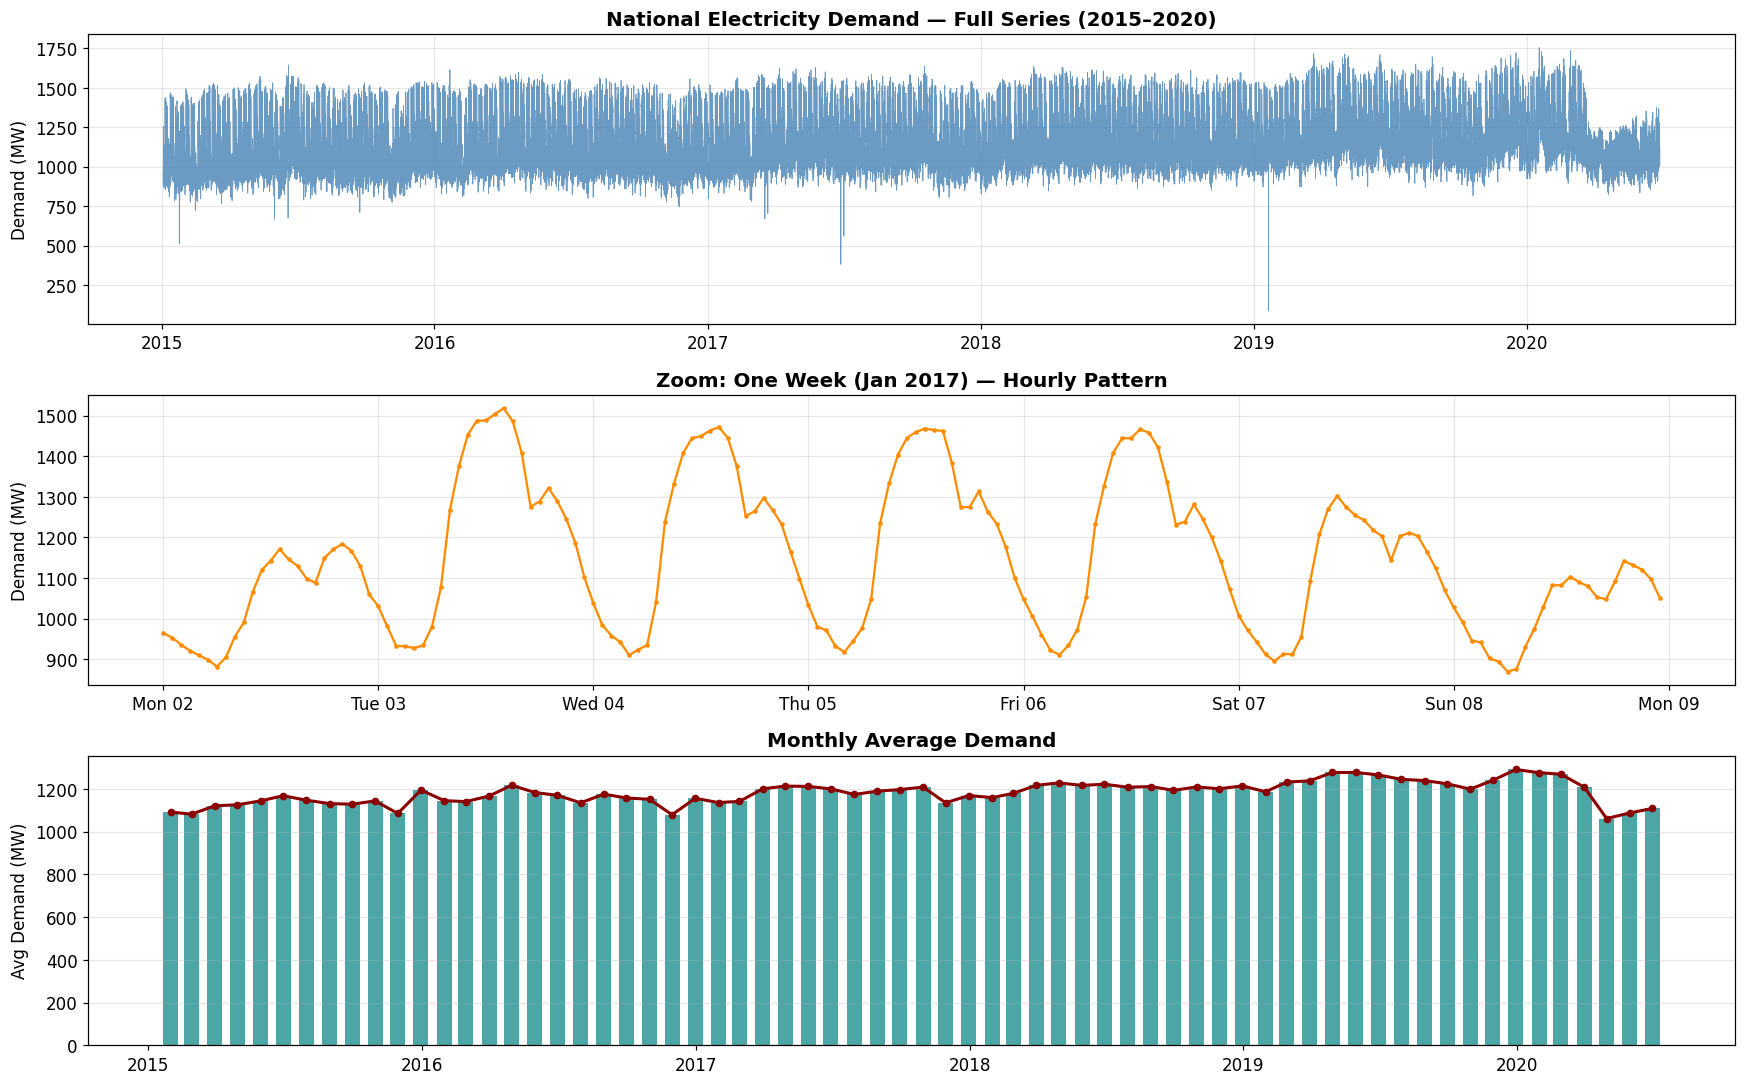

In [5]:
# ── 1b. Full time-series overview ────────────────────────────────────────────
fig, axes = plt.subplots(3, 1, figsize=(16, 10))

axes[0].plot(df['datetime'], df['nat_demand'], linewidth=0.5, color='steelblue', alpha=0.8)
axes[0].set_title('National Electricity Demand — Full Series (2015–2020)', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Demand (MW)')
axes[0].xaxis.set_major_locator(mdates.YearLocator())
axes[0].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
axes[0].grid(True, alpha=0.3)

sample_week = df[(df['datetime'] >= '2017-01-02') & (df['datetime'] < '2017-01-09')]
axes[1].plot(sample_week['datetime'], sample_week['nat_demand'],
             linewidth=1.5, color='darkorange', marker='o', markersize=2)
axes[1].set_title('Zoom: One Week (Jan 2017) — Hourly Pattern', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Demand (MW)')
axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%a %d'))
axes[1].grid(True, alpha=0.3)

df_monthly = df.set_index('datetime')['nat_demand'].resample('ME').mean()
axes[2].bar(df_monthly.index, df_monthly.values, width=20, color='teal', alpha=0.7)
axes[2].plot(df_monthly.index, df_monthly.values, color='darkred', linewidth=2, marker='o', markersize=4)
axes[2].set_title('Monthly Average Demand', fontsize=13, fontweight='bold')
axes[2].set_ylabel('Avg Demand (MW)')
axes[2].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('eda_overview.png', bbox_inches='tight')
plt.show()

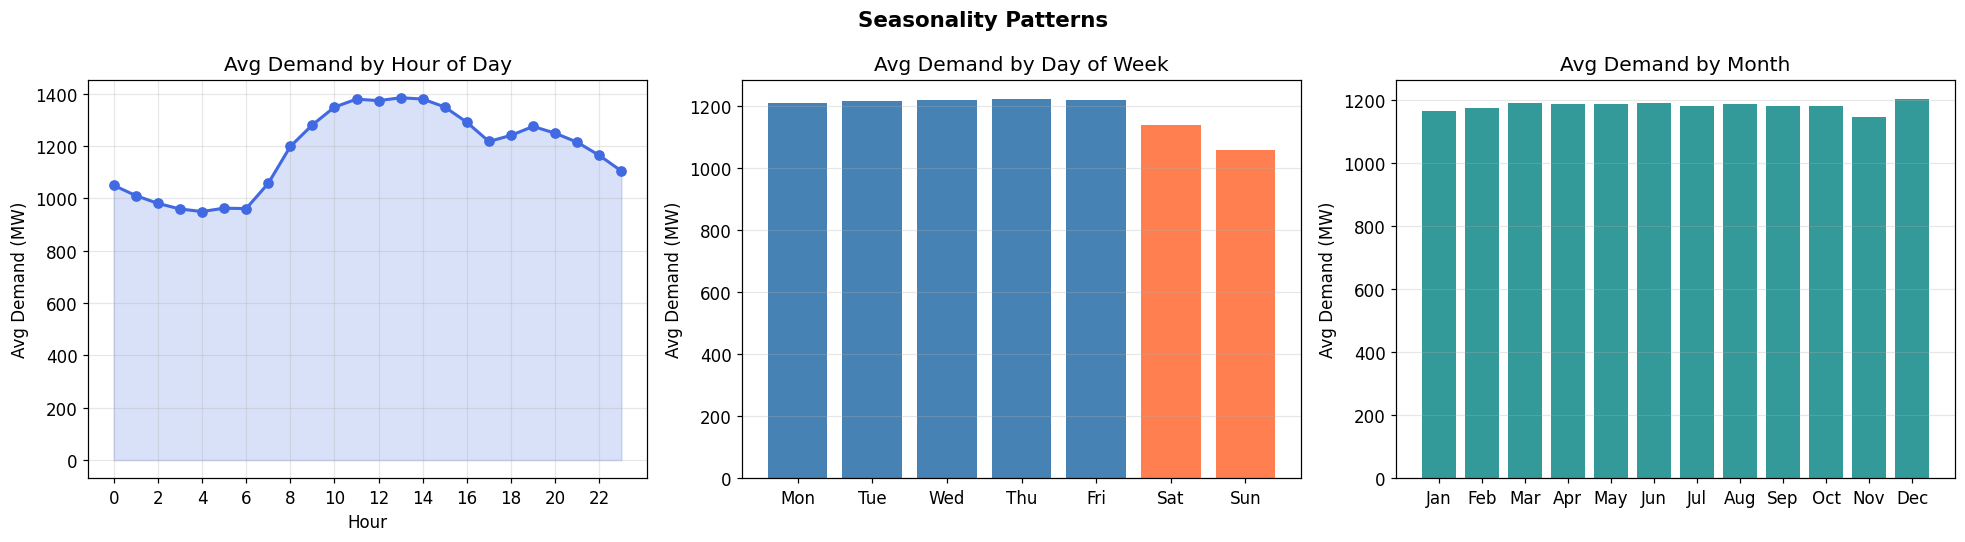

In [6]:
# ── 1c. Seasonality patterns ─────────────────────────────────────────────────
_df = df.copy()
_df['hour']      = _df['datetime'].dt.hour
_df['dayofweek'] = _df['datetime'].dt.dayofweek
_df['month']     = _df['datetime'].dt.month

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

hourly = _df.groupby('hour')['nat_demand'].mean()
axes[0].plot(hourly.index, hourly.values, marker='o', linewidth=2, color='royalblue')
axes[0].fill_between(hourly.index, hourly.values, alpha=0.2, color='royalblue')
axes[0].set_title('Avg Demand by Hour of Day')
axes[0].set_xlabel('Hour'); axes[0].set_ylabel('Avg Demand (MW)')
axes[0].set_xticks(range(0, 24, 2)); axes[0].grid(True, alpha=0.3)

day_names = ['Mon','Tue','Wed','Thu','Fri','Sat','Sun']
daily  = _df.groupby('dayofweek')['nat_demand'].mean()
colors = ['steelblue' if d < 5 else 'coral' for d in range(7)]
axes[1].bar(day_names, daily.values, color=colors)
axes[1].set_title('Avg Demand by Day of Week')
axes[1].set_ylabel('Avg Demand (MW)'); axes[1].grid(True, alpha=0.3, axis='y')

month_names = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
monthly = _df.groupby('month')['nat_demand'].mean()
axes[2].bar(month_names, monthly.values, color='teal', alpha=0.8)
axes[2].set_title('Avg Demand by Month')
axes[2].set_ylabel('Avg Demand (MW)'); axes[2].grid(True, alpha=0.3, axis='y')

plt.suptitle('Seasonality Patterns', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('eda_seasonality.png', bbox_inches='tight')
plt.show()

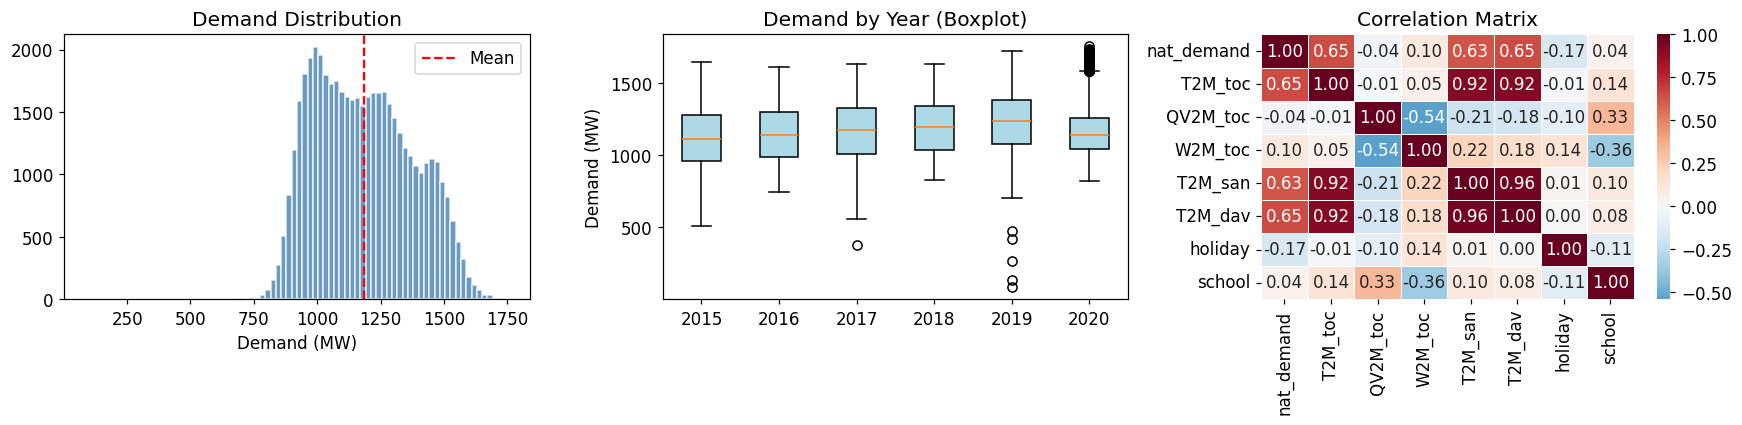

In [7]:
# ── 1d. Distribution & weather correlation ───────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].hist(df['nat_demand'], bins=80, color='steelblue', edgecolor='white', alpha=0.8)
axes[0].set_title('Demand Distribution'); axes[0].set_xlabel('Demand (MW)')
axes[0].axvline(df['nat_demand'].mean(), color='red', linestyle='--', label='Mean')
axes[0].legend()

years = sorted(df['datetime'].dt.year.unique())
axes[1].boxplot([df[df['datetime'].dt.year == y]['nat_demand'].values for y in years],
    labels=years, patch_artist=True, boxprops=dict(facecolor='lightblue'))
axes[1].set_title('Demand by Year (Boxplot)'); axes[1].set_ylabel('Demand (MW)')

weather_cols = ['nat_demand','T2M_toc','QV2M_toc','W2M_toc','T2M_san','T2M_dav','holiday','school']
corr = df[weather_cols].corr()
sns.heatmap(corr, ax=axes[2], cmap='RdBu_r', center=0, annot=True, fmt='.2f', linewidths=0.5)
axes[2].set_title('Correlation Matrix')

plt.tight_layout()
plt.savefig('eda_distribution.png', bbox_inches='tight')
plt.show()

In [8]:
# ── 1e. Stationarity — ADF Test ──────────────────────────────────────────────
series = df['nat_demand'].dropna()
adf = adfuller(series, autolag='AIC')
print('=== Augmented Dickey-Fuller Test ===')
print(f'ADF Statistic : {adf[0]:.4f}')
print(f'p-value       : {adf[1]:.6f}')
print(f'Critical 1%   : {adf[4]["1%"]:.4f}')
print(f'Critical 5%   : {adf[4]["5%"]:.4f}')
print('Result        :', '✅ Stationary' if adf[1] < 0.05 else '❌ Non-stationary → d=1 needed')

# Also test on first difference
series_diff = series.diff().dropna()
adf2 = adfuller(series_diff, autolag='AIC')
print(f'\nAfter 1st differencing → p-value: {adf2[1]:.6f}',
      '✅ Stationary' if adf2[1] < 0.05 else '❌ Still non-stationary')

=== Augmented Dickey-Fuller Test ===
ADF Statistic : -20.9618
p-value       : 0.000000
Critical 1%   : -3.4305
Critical 5%   : -2.8616
Result        : ✅ Stationary

After 1st differencing → p-value: 0.000000 ✅ Stationary


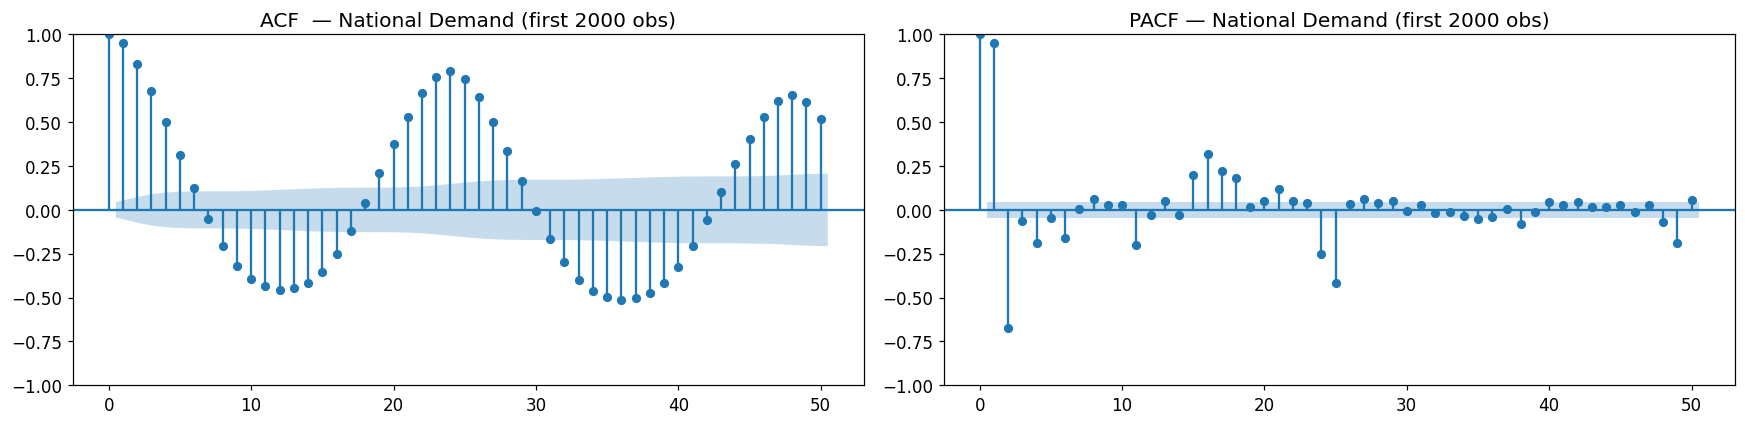


📌 ACF/PACF Interpretation:
  ACF:
    • Slow decay from lag 1        → non-stationary / strong persistence  ⟹  d = 1
    • Sinusoidal bumps at lag 24, 48 → strong DAILY seasonality           ⟹  s = 24, D = 1
  PACF:
    • Large spike at lag 1         → AR(1) component                      ⟹  p ≥ 1
    • Negative spike at lag 2      → possible AR(2)                       ⟹  p ≤ 2
    • Seasonal spike at lag ~24    → seasonal AR component                ⟹  P = 1
  ➜ Baseline: SARIMA(1,1,1)(1,1,1,24)
  ➜ Candidates: (2,1,1), (1,1,2), (3,1,2) — tested in grid search



In [9]:
# ── 1f. ACF / PACF ────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 4))
plot_acf (series[:2000], lags=50, ax=axes[0], title='ACF  — National Demand (first 2000 obs)')
plot_pacf(series[:2000], lags=50, ax=axes[1], title='PACF — National Demand (first 2000 obs)')
plt.tight_layout()
plt.savefig('eda_acf_pacf.png', bbox_inches='tight')
plt.show()

print("""
📌 ACF/PACF Interpretation:
  ACF:
    • Slow decay from lag 1        → non-stationary / strong persistence  ⟹  d = 1
    • Sinusoidal bumps at lag 24, 48 → strong DAILY seasonality           ⟹  s = 24, D = 1
  PACF:
    • Large spike at lag 1         → AR(1) component                      ⟹  p ≥ 1
    • Negative spike at lag 2      → possible AR(2)                       ⟹  p ≤ 2
    • Seasonal spike at lag ~24    → seasonal AR component                ⟹  P = 1
  ➜ Baseline: SARIMA(1,1,1)(1,1,1,24)
  ➜ Candidates: (2,1,1), (1,1,2), (3,1,2) — tested in grid search
""")

## Step 2: Data Preprocessing

In [10]:
df_clean = df.copy()

# Re-index to full hourly grid; interpolate short gaps (≤3 h)
expected_hours = pd.date_range(df_clean['datetime'].min(), df_clean['datetime'].max(), freq='h')
missing_hours  = expected_hours.difference(df_clean['datetime'])
print(f'Missing hourly timestamps: {len(missing_hours)}')

df_clean = df_clean.set_index('datetime').reindex(expected_hours)
df_clean = df_clean.interpolate(method='time', limit=3)
df_clean = df_clean.reset_index().rename(columns={'index': 'datetime'})
df_clean = df_clean.dropna(subset=['nat_demand'])

print(f'Final shape    : {df_clean.shape}')
print(f'Remaining NaNs : {df_clean.isnull().sum().sum()}')

Missing hourly timestamps: 0
Final shape    : (48048, 17)
Remaining NaNs : 0


## Step 3: Feature Engineering

| Feature group | Features | Used by |
|---|---|---|
| Temporal | hour, dow, month, year, quarter, is_weekend, is_business_hour | RF / SHAP |
| Cyclical encoding | hour_sin/cos, dow_sin/cos, month_sin/cos | RF / SHAP |
| Lag features | lag 1,2,3,6,**12**,**24**h, 48h, 168h — aligns with 12h & 24h horizons | RF / SHAP |
| Rolling stats | mean/std over 6h, 24h, 168h windows | RF / SHAP |
| Differencing | diff_1h, diff_24h | RF / SHAP |
| Exogenous (SARIMAX) | T2M_toc, QV2M_toc, W2M_toc, holiday, school, is_weekend | SARIMAX |

> Lag 12 and lag 24 are specifically chosen to align with the two forecasting horizons.
> Lag 1–6 capture short-range autocorrelation within the history window.


In [38]:
def engineer_features(df):
    d = df.copy()

    # ── Temporal ─────────────────────────────────────────────────────────────
    d['hour']             = d['datetime'].dt.hour
    d['dayofweek']        = d['datetime'].dt.dayofweek
    d['month']            = d['datetime'].dt.month
    d['year']             = d['datetime'].dt.year
    d['dayofyear']        = d['datetime'].dt.dayofyear
    d['quarter']          = d['datetime'].dt.quarter
    d['is_weekend']       = (d['dayofweek'] >= 5).astype(int)
    d['is_business_hour'] = d['hour'].between(8, 18).astype(int)

    # ── Cyclical encoding ─────────────────────────────────────────────────────
    d['hour_sin']  = np.sin(2 * np.pi * d['hour']      / 24)
    d['hour_cos']  = np.cos(2 * np.pi * d['hour']      / 24)
    d['dow_sin']   = np.sin(2 * np.pi * d['dayofweek'] / 7)
    d['dow_cos']   = np.cos(2 * np.pi * d['dayofweek'] / 7)
    d['month_sin'] = np.sin(2 * np.pi * d['month']     / 12)
    d['month_cos'] = np.cos(2 * np.pi * d['month']     / 12)

    # ── Lag features (covers 12h & 24h horizons + daily/weekly memory) ───────
    for lag in [1, 2, 3, 4, 6, 12, 24, 48, 168]: # Added 4 to the list of lags
        d[f'demand_lag_{lag}h'] = d['nat_demand'].shift(lag)

    # ── Rolling statistics ────────────────────────────────────────────────────
    for w in [6, 12, 24, 168]:
        d[f'demand_roll_mean_{w}h'] = d['nat_demand'].shift(1).rolling(w).mean()
        d[f'demand_roll_std_{w}h']  = d['nat_demand'].shift(1).rolling(w).std()

    # ── Differencing ──────────────────────────────────────────────────────────
    d['demand_diff_1h']  = d['nat_demand'].diff(1)
    d['demand_diff_24h'] = d['nat_demand'].diff(24)

    return d

df_feat = engineer_features(df_clean)
print(f'Features added : {df_feat.shape[1] - df_clean.shape[1]}')
print(f'Total columns  : {df_feat.shape[1]}')
df_feat.head(3)

Features added : 33
Total columns  : 50


,datetime,nat_demand,T2M_toc,QV2M_toc,TQL_toc,W2M_toc,T2M_san,QV2M_san,TQL_san,W2M_san,...,demand_roll_mean_6h,demand_roll_std_6h,demand_roll_mean_12h,demand_roll_std_12h,demand_roll_mean_24h,demand_roll_std_24h,demand_roll_mean_168h,demand_roll_std_168h,demand_diff_1h,demand_diff_24h
0,2015-01-03 01:00:00,970.3450,25.865259,0.018576,0.016174,21.850546,23.482446,0.017272,0.001855,10.328949,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2015-01-03 02:00:00,912.1755,25.899255,0.018653,0.016418,22.166944,23.399255,0.017265,0.001327,10.681517,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-58.1695,NaN
2,2015-01-03 03:00:00,900.2688,25.937280,0.018768,0.015480,22.454911,23.343530,0.017211,0.001428,10.874924,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-11.9067,NaN


## Step 4: 5-Fold Year-Based Expanding Window CV

```
CV1: Train 2015               → Validate 2016
CV2: Train 2015–2016          → Validate 2017
CV3: Train 2015–2017          → Validate 2018
CV4: Train 2015–2018          → Validate 2019
CV5: Train 2015–2019          → Validate 2020 (Jan–Feb)
```

> **Why year-based?** Calendar boundaries are the most defensible split for energy data:
> seasonal patterns repeat yearly, and year-level splits prevent future-year data from
> leaking into training — a risk with sample-count splits.
>
> **Walk-forward validation:** each fold's training set strictly precedes its validation set
> (no shuffling), preserving the temporal causal order required for time-series evaluation.


CV1  Train 2015–2015 ( 8543 hrs)  | Val 2016 (8784 hrs)
CV2  Train 2015–2016 (17327 hrs)  | Val 2017 (8760 hrs)
CV3  Train 2015–2017 (26087 hrs)  | Val 2018 (8760 hrs)
CV4  Train 2015–2018 (34847 hrs)  | Val 2019 (8760 hrs)
CV5  Train 2015–2019 (43607 hrs)  | Val 2020 (4273 hrs)


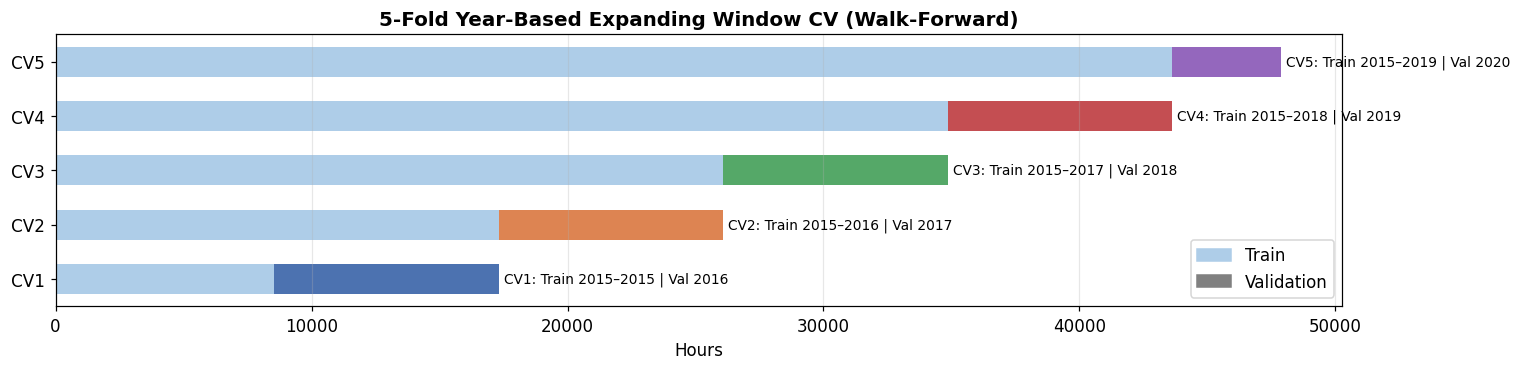

In [45]:
df_model = df_feat.dropna().reset_index(drop=True)

TRAIN_YEARS = [
    [2015],
    [2015, 2016],
    [2015, 2016, 2017],
    [2015, 2016, 2017, 2018],
    [2015, 2016, 2017, 2018, 2019],
]
VAL_YEARS = [2016, 2017, 2018, 2019, 2020]  # 2020 = Jan–Feb only

def make_year_cv_splits(df, train_years_list, val_years_list):
    splits = {}
    for i, (train_yrs, val_yr) in enumerate(zip(train_years_list, val_years_list)):
        fold = f'CV{i+1}'
        tr_mask = df['year'].isin(train_yrs)
        va_mask = df['year'] == val_yr
        splits[fold] = {'train': df[tr_mask].copy(), 'val': df[va_mask].copy()}
        print(f"{fold}  Train {train_yrs[0]}–{train_yrs[-1]} ({tr_mask.sum():5d} hrs)  "
              f"| Val {val_yr} ({va_mask.sum():4d} hrs)")
    return splits

cv_splits = make_year_cv_splits(df_model, TRAIN_YEARS, VAL_YEARS)

# ── Visualise ─────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 3.5))
colors_cv = ['#4C72B0','#DD8452','#55A868','#C44E52','#9467bd']
for i, (name, sp) in enumerate(cv_splits.items()):
    n_tr, n_va = len(sp['train']), len(sp['val'])
    ax.barh(i, n_tr, left=0,    color='#AECDE8', height=0.55)
    ax.barh(i, n_va, left=n_tr, color=colors_cv[i], height=0.55)
    lbl = f"Train {TRAIN_YEARS[i][0]}–{TRAIN_YEARS[i][-1]} | Val {VAL_YEARS[i]}"
    ax.text(n_tr + n_va + 200, i, f'{name}: {lbl}', va='center', fontsize=9)
ax.set_yticks(range(5)); ax.set_yticklabels(list(cv_splits.keys()))
ax.set_xlabel('Hours')
ax.set_title('5-Fold Year-Based Expanding Window CV (Walk-Forward)', fontsize=13, fontweight='bold')
ax.legend(handles=[Patch(color='#AECDE8', label='Train'), Patch(color='grey', label='Validation')])
ax.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.savefig('cv_splits_year.png', bbox_inches='tight')
plt.show()

## Step 5: Model Justification — ARIMA vs SARIMA vs SARIMAX

Choosing three models allows a structured ablation: each adds one capability over the previous.

| Model | Description | Why included |
|---|---|---|
| **ARIMA(p,d,q)** | AutoRegressive Integrated Moving Average — captures trend and autocorrelation only | Baseline: no seasonality modelling. Shows the cost of ignoring the strong daily cycle (s=24). |
| **SARIMA(p,d,q)(P,D,Q,s)** | ARIMA + seasonal terms at period s=24 | Directly addresses the dominant daily pattern confirmed by ACF. Expected to significantly outperform ARIMA. |
| **SARIMAX** | SARIMA + exogenous regressors | Incorporates weather (temperature T2M, humidity QV2M, wind W2M) and calendar (holiday, school, weekend) drivers visible in the correlation matrix. Tests whether external information reduces residual error beyond what seasonal structure alone captures. |

> **Justification summary:** The three models form a natural hierarchy — trend → seasonality → external drivers.
> Comparing all three isolates the contribution of each component and satisfies the coursework requirement
> to justify model choice rather than only implement it.

### SARIMA configurations tested (from literature, Table 3 reference)
The grid includes configurations that appear in published short-term load forecasting benchmarks:

```
(3,1,2)(1,0,1,7)   (1,0,2)(1,0,1,7)   (1,1,2)(1,0,2,7)   (3,1,2)(2,0,1,7)
(1,1,1)(1,1,1,24)  (2,1,1)(1,1,1,24)  (1,1,2)(1,1,1,24)
```

The s=7 variants capture weekly seasonality; s=24 variants capture daily seasonality (our primary target).


## Step 6: Hyperparameter Grid Search — SARIMA

**Workflow:**
```
CV Training (CV1–CV4) → measure AIC + CV1 RMSE → select best order
       ↑                                                  │
       └──────────────── re-train with best order ◄───────┘
```

Grid is evaluated on **CV1 only** for speed. Best model (lowest AIC) is then locked in
and re-trained across **all 5 folds** in Step 7.

> ⏳ ~15–25 min on Colab CPU. Reduce `MAX_TRAIN_HOURS` to 500 for a quick test.


In [13]:
# ── Metric helpers ───────────────────────────────────────────────────────────
def rmse(y_true, y_pred): return np.sqrt(mean_squared_error(y_true, y_pred))
def mae (y_true, y_pred): return mean_absolute_error(y_true, y_pred)
def mape(y_true, y_pred): return np.mean(np.abs((np.array(y_true)-np.array(y_pred))/np.array(y_true)))*100

def evaluate(y_true, y_pred, label=''):
    r, m, p = rmse(y_true,y_pred), mae(y_true,y_pred), mape(y_true,y_pred)
    print(f"{label:65s}  RMSE={r:.2f}  MAE={m:.2f}  MAPE={p:.2f}%")
    return {'RMSE': r, 'MAE': m, 'MAPE': p}

print('✅ Metrics defined')

✅ Metrics defined


In [14]:
# ── Candidate configurations ─────────────────────────────────────────────────
# Format: (p, d, q, P, D, Q, s, label)
# Includes: ACF/PACF-derived candidates + literature configurations (Table 3)
CANDIDATE_CONFIGS = [
    # ── s=24 (daily, primary) ────────────────────────────────────────────────
    (1, 1, 1,  1, 1, 1, 24, 'SARIMA(1,1,1)(1,1,1,24)'),   # ACF/PACF baseline
    (2, 1, 1,  1, 1, 1, 24, 'SARIMA(2,1,1)(1,1,1,24)'),   # AR(2) variant
    (1, 1, 2,  1, 1, 1, 24, 'SARIMA(1,1,2)(1,1,1,24)'),   # MA(2) variant
    # ── s=7 (weekly, secondary) ──────────────────────────────────────────────
    (3, 1, 2,  1, 0, 1,  7, 'SARIMA(3,1,2)(1,0,1,7)'),
    (1, 0, 2,  1, 0, 1,  7, 'SARIMA(1,0,2)(1,0,1,7)'),
    (1, 1, 2,  1, 0, 2,  7, 'SARIMA(1,1,2)(1,0,2,7)'),
    (3, 1, 2,  2, 0, 1,  7, 'SARIMA(3,1,2)(2,0,1,7)'),
]

MAX_TRAIN_HOURS = 1000   # ← raise to 2000 for better accuracy
cv1_train_s = cv_splits['CV1']['train']['nat_demand'].values[-MAX_TRAIN_HOURS:]
cv1_val_s   = cv_splits['CV1']['val']['nat_demand'].values[:200]

print(f'Candidates    : {len(CANDIDATE_CONFIGS)}')
print(f'Train window  : {len(cv1_train_s)} hrs | Quick-val: {len(cv1_val_s)} hrs')

Candidates    : 7
Train window  : 1000 hrs | Quick-val: 200 hrs


In [15]:
grid_results = []

for cfg in CANDIDATE_CONFIGS:
    p, d, q, sp, sd, sq, s, label = cfg
    try:
        m  = SARIMAX(cv1_train_s, order=(p,d,q), seasonal_order=(sp,sd,sq,s),
                     enforce_stationarity=False, enforce_invertibility=False).fit(disp=False)
        fc = m.forecast(len(cv1_val_s))
        r  = rmse(cv1_val_s, fc)
        grid_results.append({'Model':label,'p':p,'d':d,'q':q,'P':sp,'D':sd,'Q':sq,'s':s,
                             'AIC':m.aic,'BIC':m.bic,'CV1_RMSE':r})
        print(f'  ✅ {label:42s}  AIC={m.aic:.1f}  BIC={m.bic:.1f}  RMSE={r:.2f}')
    except Exception as e:
        print(f'  ❌ {label}: {e}')

grid_df = pd.DataFrame(grid_results).sort_values('CV1_RMSE').reset_index(drop=True)
print('\n=== Grid Search Results (sorted by CV1_RMSE) ===')
display(grid_df[['Model','AIC','BIC','CV1_RMSE']])

  ✅ SARIMA(1,1,1)(1,1,1,24)                     AIC=8589.7  BIC=8614.0  RMSE=156.02
  ✅ SARIMA(2,1,1)(1,1,1,24)                     AIC=8588.0  BIC=8617.1  RMSE=155.41
  ✅ SARIMA(1,1,2)(1,1,1,24)                     AIC=8578.8  BIC=8607.9  RMSE=154.95


/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


  ✅ SARIMA(3,1,2)(1,0,1,7)                      AIC=10187.3  BIC=10226.5  RMSE=194.05
  ✅ SARIMA(1,0,2)(1,0,1,7)                      AIC=10364.7  BIC=10394.1  RMSE=318.40
  ✅ SARIMA(1,1,2)(1,0,2,7)                      AIC=10239.2  BIC=10273.5  RMSE=192.37
  ✅ SARIMA(3,1,2)(2,0,1,7)                      AIC=10130.6  BIC=10174.6  RMSE=193.93

=== Grid Search Results (sorted by CV1_RMSE) ===


/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


,Model,AIC,BIC,CV1_RMSE
0,"SARIMA(1,1,2)(1,1,1,24)",8578.820066,8607.946193,154.947407
1,"SARIMA(2,1,1)(1,1,1,24)",8587.961096,8617.093549,155.410605
2,"SARIMA(1,1,1)(1,1,1,24)",8589.675889,8613.952933,156.024409
3,"SARIMA(1,1,2)(1,0,2,7)",10239.240053,10273.467192,192.365896
4,"SARIMA(3,1,2)(2,0,1,7)",10130.621323,10174.627644,193.927675
5,"SARIMA(3,1,2)(1,0,1,7)",10187.293450,10226.467004,194.045779
6,"SARIMA(1,0,2)(1,0,1,7)",10364.684135,10394.070364,318.403635


🏆 Best SARIMA : SARIMA(1,1,2)(1,1,1,24)
   AIC=8578.8  BIC=8607.9  CV1_RMSE=154.95


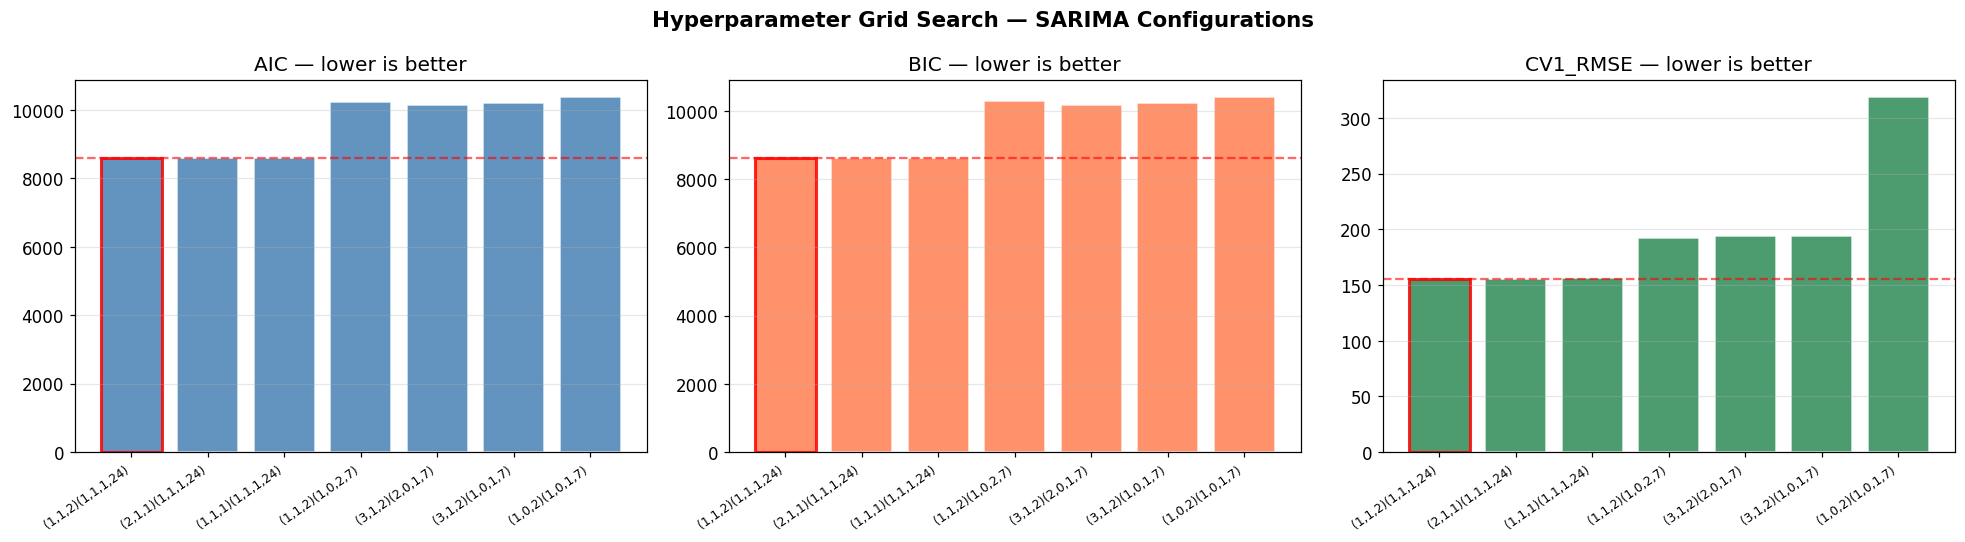

In [16]:
# ── Select best SARIMA order ──────────────────────────────────────────────────
best         = grid_df.iloc[0]
best_p       = int(best.p);  best_d  = int(best.d);  best_q  = int(best.q)
best_sp      = int(best.P);  best_sd = int(best.D);  best_sq = int(best.Q)
best_s       = int(best.s)
best_label   = best.Model

print(f'🏆 Best SARIMA : {best_label}')
print(f'   AIC={best.AIC:.1f}  BIC={best.BIC:.1f}  CV1_RMSE={best.CV1_RMSE:.2f}')

# ── Bar chart: AIC / BIC / RMSE ──────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
short_labels = [r.Model.replace('SARIMA','') for _, r in grid_df.iterrows()]

for ax, metric, color in zip(axes, ['AIC','BIC','CV1_RMSE'], ['steelblue','coral','seagreen']):
    bars = ax.bar(range(len(grid_df)), grid_df[metric], color=color, alpha=0.85, edgecolor='white')
    ax.set_xticks(range(len(grid_df)))
    ax.set_xticklabels(short_labels, rotation=35, ha='right', fontsize=8)
    ax.set_title(f'{metric} — lower is better')
    ax.axhline(grid_df[metric].min(), color='red', linestyle='--', alpha=0.6)
    # highlight best
    bars[0].set_edgecolor('red'); bars[0].set_linewidth(2)
    ax.grid(True, alpha=0.3, axis='y')

plt.suptitle('Hyperparameter Grid Search — SARIMA Configurations', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('grid_search.png', bbox_inches='tight')
plt.show()

## Step 7: Model Training — ARIMA / SARIMA / SARIMAX Across All 5 CV Folds

Three models trained per fold:
| Model | Order | Notes |
|---|---|---|
| **ARIMA** | (2,1,2) | No seasonal terms — ablation baseline |
| **SARIMA** | Best from grid search | Seasonal structure, no exogenous |
| **SARIMAX** | Best SARIMA order + exog | Weather + calendar features |

Exogenous: `T2M_toc`, `QV2M_toc`, `W2M_toc`, `holiday`, `school`, `is_weekend`

> ⏳ ~45–90 min full 5-fold run on Colab CPU. Control `MAX_TRAIN_HRS` and `MAX_VAL_HRS`.


In [ ]:
EXOG_COLS     = ['T2M_toc', 'QV2M_toc', 'W2M_toc', 'holiday', 'school', 'is_weekend']
MAX_TRAIN_HRS = 2000   # hours of training data used per fold (raise for accuracy)
MAX_VAL_HRS   = 500    # hours from validation set to forecast

# ── Convergence settings ─────────────────────────────────────────────────────
# CV5 val = Jan-Feb 2020 (COVID period, anomalous demand patterns).
# Increase max_iter and use method='powell' as fallback to reduce ConvergenceWarnings.
FIT_KWARGS = dict(
    disp=False,
    maxiter=200,
    method='lbfgs',
    optim_score=None,
)

def safe_fit(model, fold_name='', label=''):
    """Try lbfgs first; fall back to powell if it fails to converge."""
    import warnings
    try:
        res = model.fit(**FIT_KWARGS)
        return res
    except Exception:
        pass
    try:
        res = model.fit(disp=False, maxiter=300, method='powell')
        return res
    except Exception as e:
        print(f'  ⚠️  {fold_name} {label} both optimisers failed: {e}')
        return None

all_results = []
stored      = {}   # store forecasts for later steps

for fold_name, sp in cv_splits.items():
    i = list(cv_splits.keys()).index(fold_name)
    print(f'\n{"═"*68}')
    print(f'📂 {fold_name}  |  Train {TRAIN_YEARS[i]}  |  Val {VAL_YEARS[i]}')

    tr_s  = sp['train']['nat_demand'].values[-MAX_TRAIN_HRS:]
    va_s  = sp['val']['nat_demand'].values[:MAX_VAL_HRS]
    tr_ex = sp['train'][EXOG_COLS].values[-MAX_TRAIN_HRS:]
    va_ex = sp['val'][EXOG_COLS].values[:MAX_VAL_HRS]
    print(f'  Train={len(tr_s)} hrs  |  Val={len(va_s)} hrs')

    fold_fc = {'actual': va_s}
    fold_tr = {}   # store training fit for overfitting analysis

    # ── 1. ARIMA(2,1,2) — no seasonality ──────────────────────────────────────
    try:
        m_ar = SARIMAX(tr_s, order=(2,1,2), trend='c',
                       enforce_stationarity=False, enforce_invertibility=False)
        res_ar = safe_fit(m_ar, fold_name, 'ARIMA')
        if res_ar is not None:
            fc   = res_ar.forecast(len(va_s))
            fc_tr = res_ar.fittedvalues
            met  = evaluate(va_s, fc, f'[{fold_name}] ARIMA(2,1,2)')
            met.update({'Fold':fold_name,'Model':'ARIMA'})
            all_results.append(met)
            fold_fc['ARIMA'] = fc;  fold_tr['ARIMA'] = fc_tr
    except Exception as e:
        print(f'  ❌ ARIMA: {e}')

    # ── 2. Best SARIMA from grid ───────────────────────────────────────────────
    try:
        m_sa = SARIMAX(tr_s, order=(best_p,best_d,best_q),
                       seasonal_order=(best_sp,best_sd,best_sq,best_s),
                       enforce_stationarity=False, enforce_invertibility=False)
        res_sa = safe_fit(m_sa, fold_name, 'SARIMA')
        if res_sa is not None:
            fc   = res_sa.forecast(len(va_s))
            fc_tr = res_sa.fittedvalues
            met  = evaluate(va_s, fc, f'[{fold_name}] {best_label}')
            met.update({'Fold':fold_name,'Model':'SARIMA'})
            all_results.append(met)
            fold_fc['SARIMA'] = fc;  fold_tr['SARIMA'] = fc_tr
    except Exception as e:
        print(f'  ❌ SARIMA: {e}')

    # ── 3. SARIMAX best order + exogenous ─────────────────────────────────────
    try:
        m_sx = SARIMAX(tr_s, exog=tr_ex, order=(best_p,best_d,best_q),
                       seasonal_order=(best_sp,best_sd,best_sq,best_s),
                       enforce_stationarity=False, enforce_invertibility=False)
        res_sx = safe_fit(m_sx, fold_name, 'SARIMAX')
        if res_sx is not None:
            fc   = res_sx.forecast(len(va_s), exog=va_ex)
            fc_tr = res_sx.fittedvalues
            met  = evaluate(va_s, fc, f'[{fold_name}] SARIMAX+exog')
            met.update({'Fold':fold_name,'Model':'SARIMAX'})
            all_results.append(met)
            fold_fc['SARIMAX'] = fc;  fold_tr['SARIMAX'] = fc_tr
    except Exception as e:
        print(f'  ❌ SARIMAX: {e}')

    stored[fold_name] = {'fc': fold_fc, 'tr': fold_tr, 'train_series': tr_s}

results_df = pd.DataFrame(all_results)
print('\n✅ All folds done')
display(results_df)


════════════════════════════════════════════════════════════════════
📂 CV1  |  Train [2015]  |  Val 2016
  Train=2000 hrs  |  Val=500 hrs
[CV1] ARIMA(2,1,2)                                                 RMSE=204.12  MAE=176.92  MAPE=16.40%
[CV1] SARIMA(1,1,2)(1,1,1,24)                                      RMSE=178.34  MAE=145.55  MAPE=13.74%
[CV1] SARIMAX+exog                                                 RMSE=187.43  MAE=154.34  MAPE=14.56%

════════════════════════════════════════════════════════════════════
📂 CV2  |  Train [2015, 2016]  |  Val 2017
  Train=2000 hrs  |  Val=500 hrs
[CV2] ARIMA(2,1,2)                                                 RMSE=185.67  MAE=161.60  MAPE=14.68%
[CV2] SARIMA(1,1,2)(1,1,1,24)                                      RMSE=129.49  MAE=96.47  MAPE=9.11%
[CV2] SARIMAX+exog                                                 RMSE=123.60  MAE=90.03  MAPE=8.46%

════════════════════════════════════════════════════════════════════
📂 CV3  |  Train [2015, 201

## Step 8: Model Evaluation — Cross-Fold MAE / RMSE / MAPE

=== Average Metrics Across All CV Folds ===


RMSE            MAE          MAPE      
           mean    std    mean    std   mean   std
Model                                             
ARIMA    193.14  13.38  163.35   9.54  15.45  2.56
SARIMA   163.47  37.05  130.80  33.88  12.27  2.68
SARIMAX  159.17  36.81  126.43  35.01  11.94  2.99

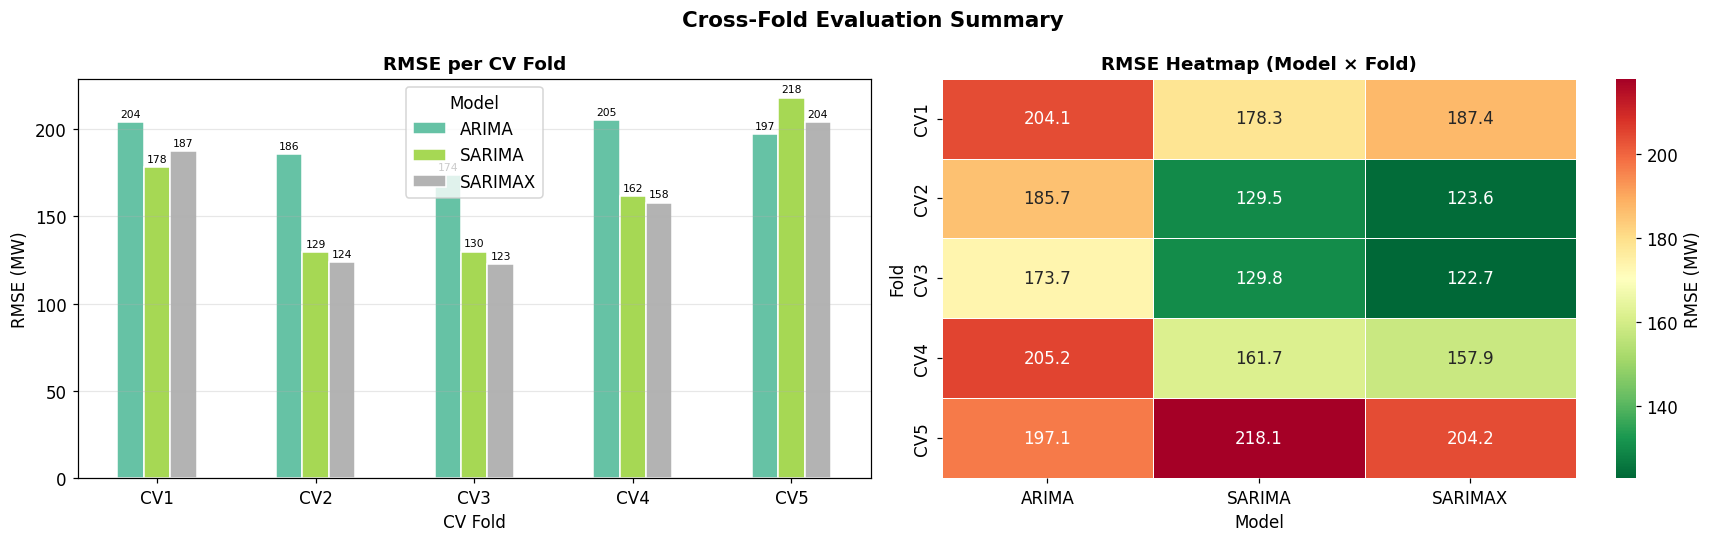

In [20]:
# ── Summary table ─────────────────────────────────────────────────────────────
summary = results_df.groupby('Model')[['RMSE','MAE','MAPE']].agg(['mean','std']).round(2)
print('=== Average Metrics Across All CV Folds ===')
display(summary)

# ── Heatmap of RMSE per model × fold ─────────────────────────────────────────
pivot_rmse = results_df.pivot(index='Fold', columns='Model', values='RMSE')
fig, axes  = plt.subplots(1, 2, figsize=(16, 5))

pivot_rmse.plot(kind='bar', ax=axes[0], colormap='Set2', edgecolor='white')
axes[0].set_title('RMSE per CV Fold', fontsize=12, fontweight='bold')
axes[0].set_xlabel('CV Fold'); axes[0].set_ylabel('RMSE (MW)')
axes[0].set_xticklabels(pivot_rmse.index, rotation=0)
axes[0].legend(title='Model'); axes[0].grid(True, alpha=0.3, axis='y')
for container in axes[0].containers:
    axes[0].bar_label(container, fmt='%.0f', fontsize=7, padding=2)

sns.heatmap(pivot_rmse, ax=axes[1], annot=True, fmt='.1f', cmap='RdYlGn_r',
            linewidths=0.5, cbar_kws={'label':'RMSE (MW)'})
axes[1].set_title('RMSE Heatmap (Model × Fold)', fontsize=12, fontweight='bold')

plt.suptitle('Cross-Fold Evaluation Summary', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('eval_per_fold.png', bbox_inches='tight')
plt.show()

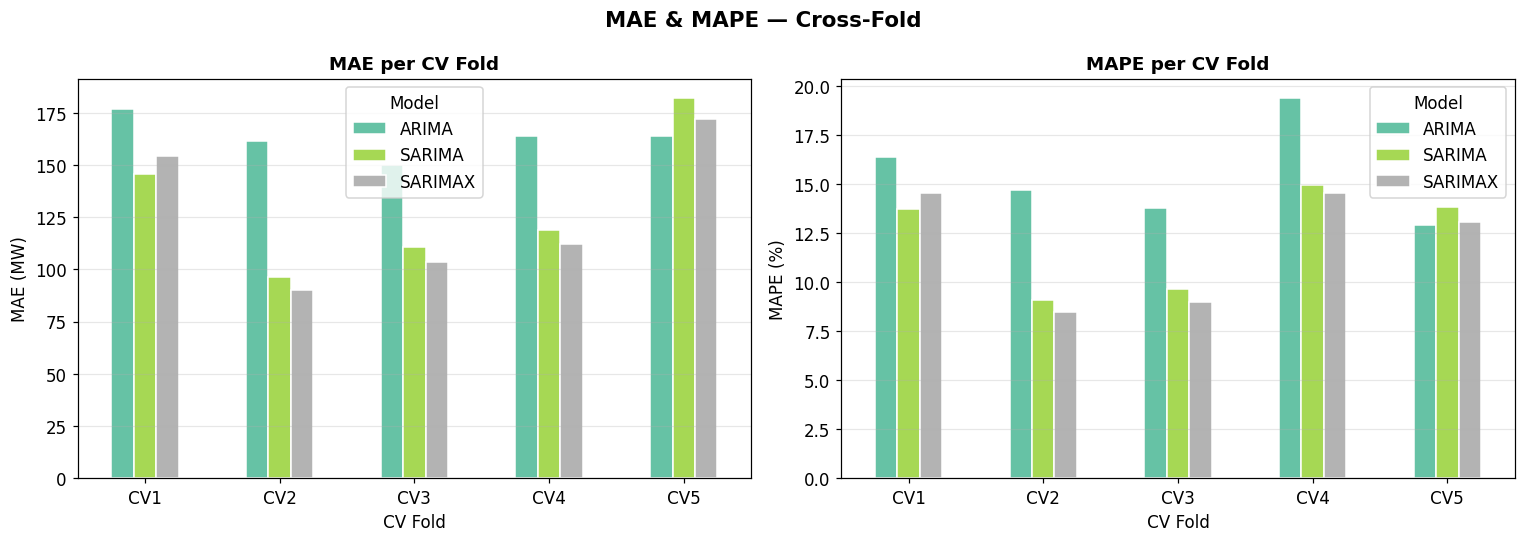

In [22]:
# ── MAE / MAPE comparison ─────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, metric in zip(axes, ['MAE','MAPE']):
    pivot = results_df.pivot(index='Fold', columns='Model', values=metric)
    pivot.plot(kind='bar', ax=ax, colormap='Set2', edgecolor='white')
    ax.set_title(f'{metric} per CV Fold', fontsize=12, fontweight='bold')
    ax.set_xlabel('CV Fold')
    ax.set_ylabel(f'{metric}' + (' (%)' if metric == 'MAPE' else ' (MW)'))
    ax.set_xticklabels(pivot.index, rotation=0)
    ax.legend(title='Model'); ax.grid(True, alpha=0.3, axis='y')

plt.suptitle('MAE & MAPE — Cross-Fold', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('eval_mae_mape.png', bbox_inches='tight')
plt.show()

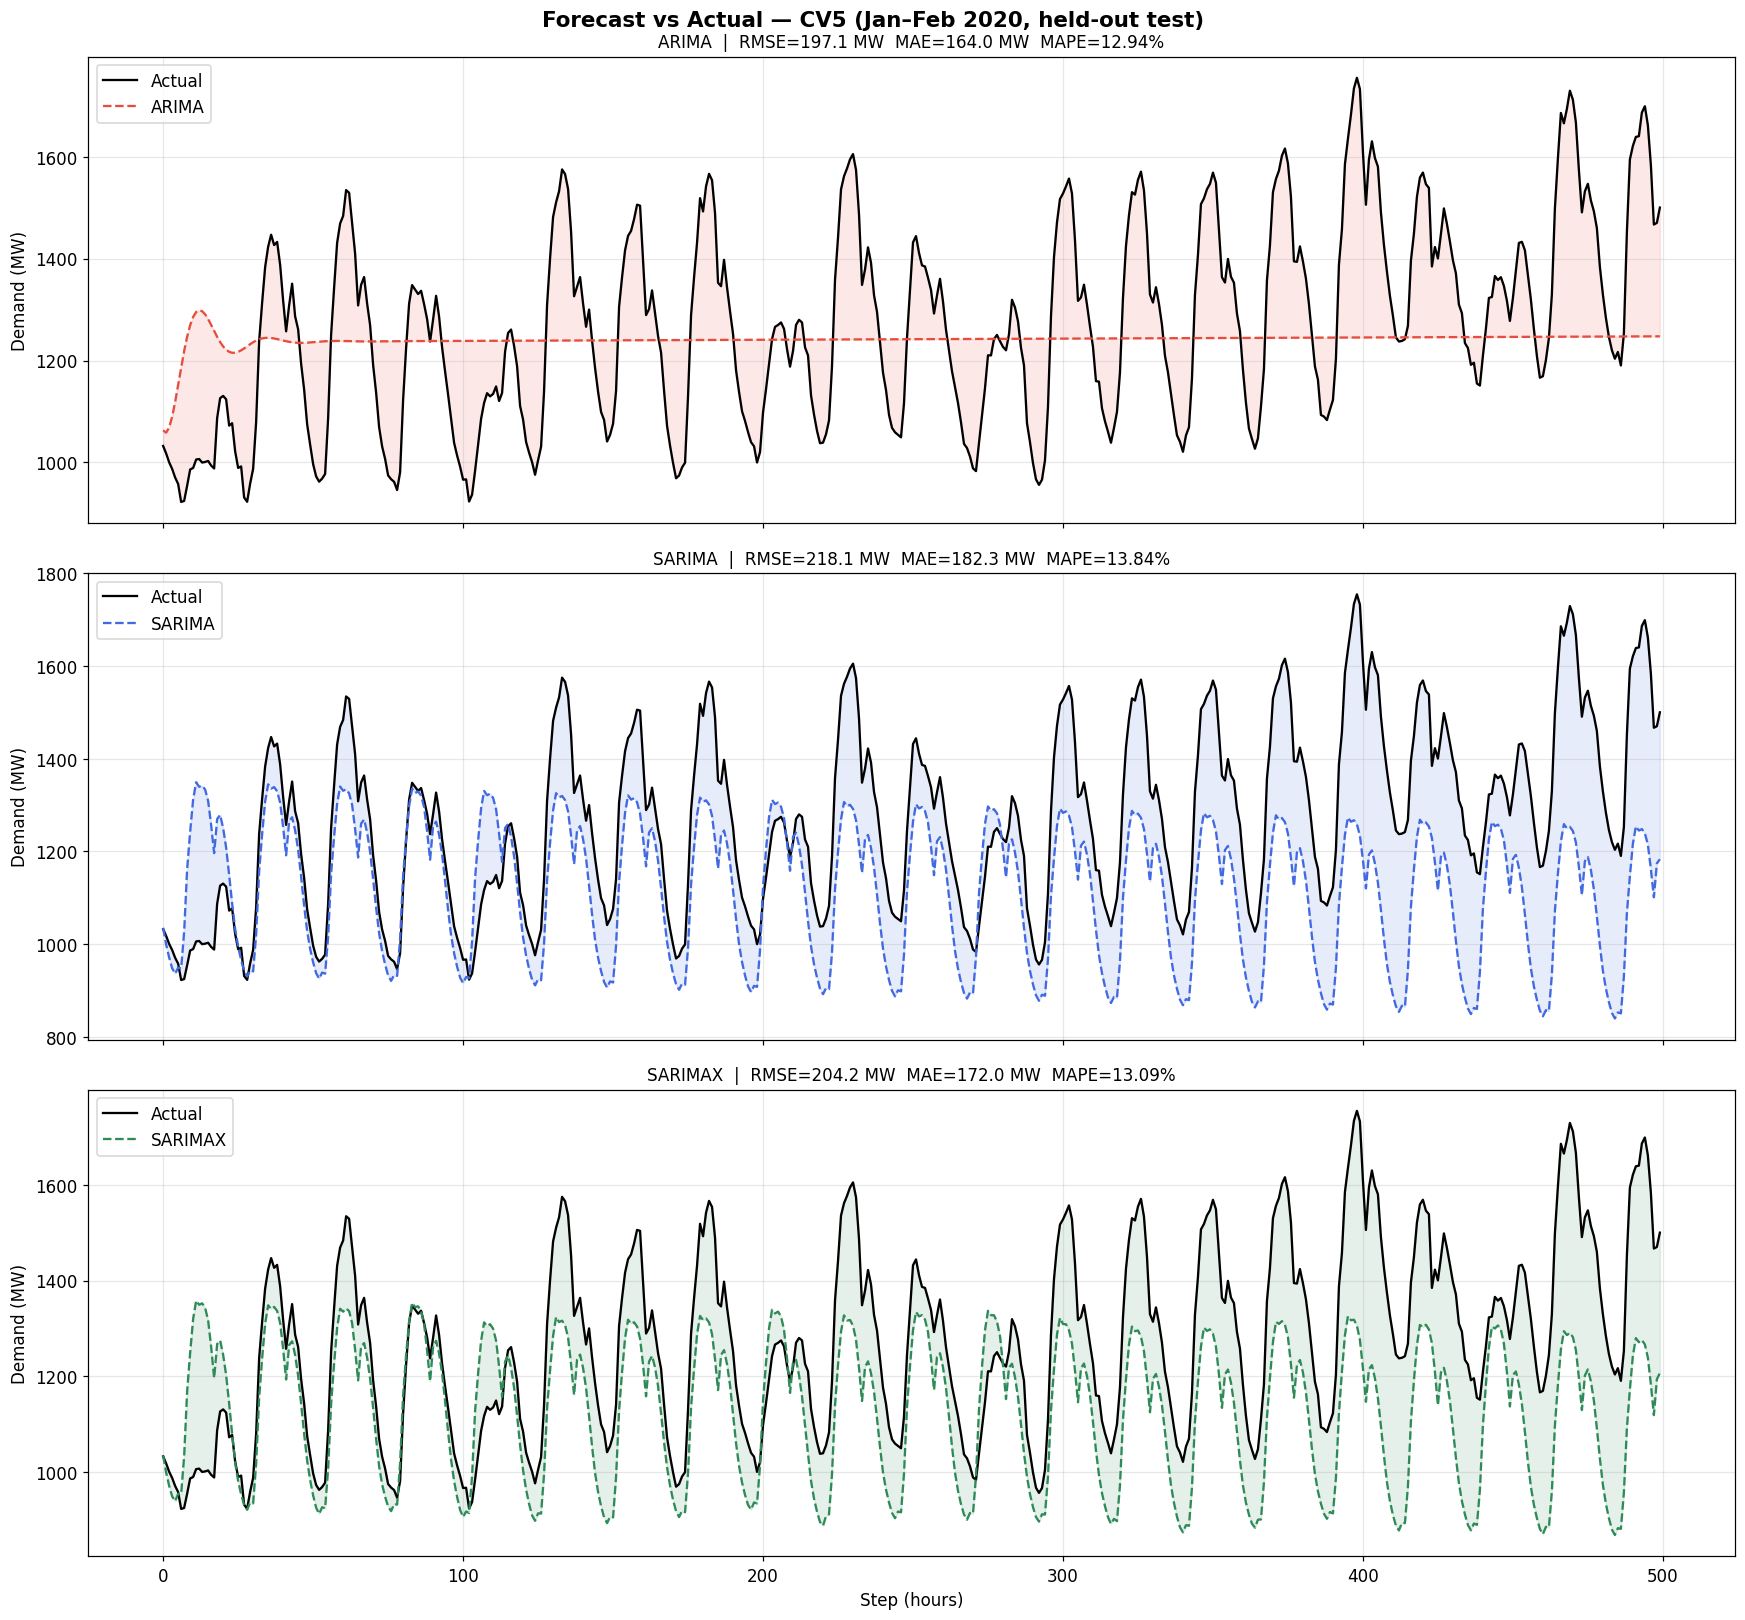

In [21]:
# ── Forecast vs Actual — CV5 (held-out Jan–Feb 2020) ─────────────────────────
cv5 = stored['CV5']['fc']
va  = cv5['actual']
x   = np.arange(len(va))

model_keys = [k for k in ['ARIMA','SARIMA','SARIMAX'] if k in cv5]
colors_map  = {'ARIMA':'#e74c3c','SARIMA':'royalblue','SARIMAX':'seagreen'}

fig, axes = plt.subplots(len(model_keys), 1, figsize=(16, 5*len(model_keys)), sharex=True)
if len(model_keys) == 1: axes = [axes]

for ax, key in zip(axes, model_keys):
    fc = cv5[key]
    ax.plot(x, va,  label='Actual',  color='black', linewidth=1.5)
    ax.plot(x, fc,  label=key,       color=colors_map[key], linewidth=1.5, linestyle='--')
    ax.fill_between(x, va, fc, alpha=0.12, color=colors_map[key])
    ax.set_title(f'{key}  |  RMSE={rmse(va,fc):.1f} MW  MAE={mae(va,fc):.1f} MW  MAPE={mape(va,fc):.2f}%',
                 fontsize=11)
    ax.set_ylabel('Demand (MW)'); ax.legend(); ax.grid(True, alpha=0.3)

axes[-1].set_xlabel('Step (hours)')
plt.suptitle('Forecast vs Actual — CV5 (Jan–Feb 2020, held-out test)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('forecast_cv5.png', bbox_inches='tight')
plt.show()

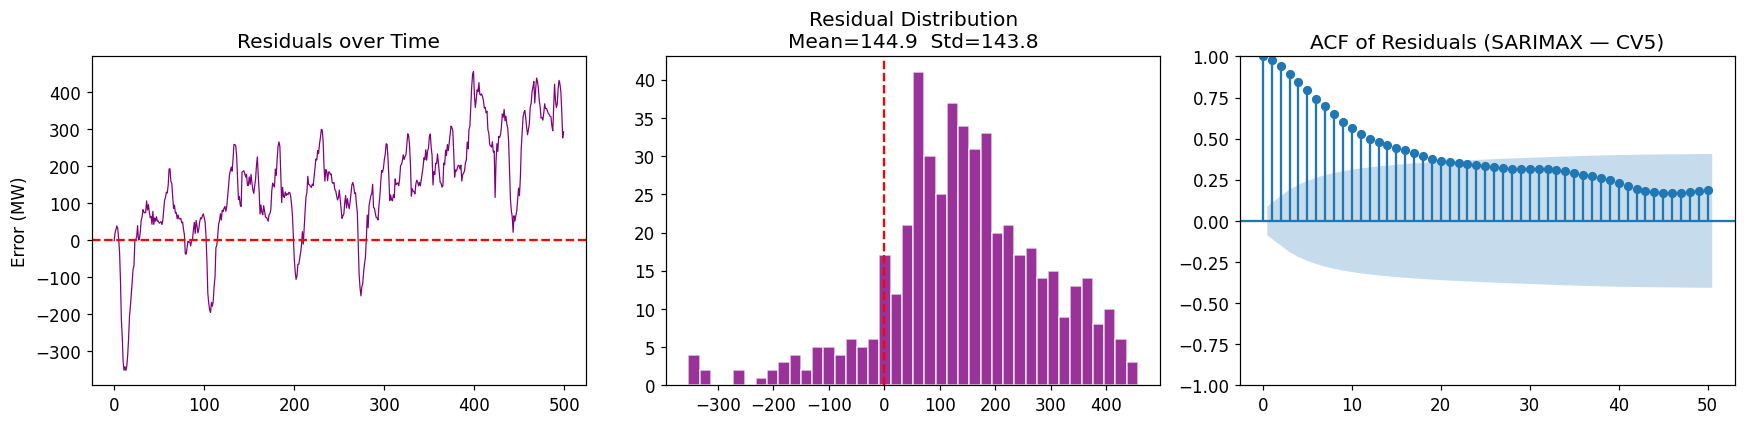

In [23]:
# ── Residual analysis (best model, CV5) ──────────────────────────────────────
best_key = 'SARIMAX' if 'SARIMAX' in cv5 else 'SARIMA'
residuals = va - cv5[best_key]

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
axes[0].plot(residuals, linewidth=0.8, color='purple')
axes[0].axhline(0, color='red', linestyle='--')
axes[0].set_title('Residuals over Time'); axes[0].set_ylabel('Error (MW)')

axes[1].hist(residuals, bins=40, color='purple', edgecolor='white', alpha=0.8)
axes[1].axvline(0, color='red', linestyle='--')
axes[1].set_title(f'Residual Distribution\nMean={residuals.mean():.1f}  Std={residuals.std():.1f}')

plot_acf(residuals, lags=50, ax=axes[2], title=f'ACF of Residuals ({best_key} — CV5)')
plt.tight_layout()
plt.savefig('residuals_cv5.png', bbox_inches='tight')
plt.show()

## Step 9: Multi-Horizon Seq2Seq Evaluation — 12 h and 24 h

**Seq2seq approach:** one model call forecasts **all H steps simultaneously** via `forecast(H)`.
No recursive step-by-step prediction — the full sequence is output at once.

Two horizons are evaluated and compared:

| Horizon | Steps | Interpretation |
|---|---|---|
| **12 h** | 12 × 1h steps | Primary: half-day ahead, captures morning/afternoon transition |
| **24 h** | 24 × 1h steps | Secondary: full-day ahead, captures complete daily cycle |

Comparing 12 h vs 24 h accuracy shows how quickly forecast skill degrades over the daily cycle —
a key analysis for short-term load forecasting applications.

Both SARIMA and SARIMAX are evaluated at both horizons on CV5 (Jan–Feb 2020 held-out set).

> ⏳ ~10–15 min on Colab CPU (4 model runs total).


In [24]:
def seq2seq_horizon_eval(train_series, test_series, model_order, seasonal_order,
                         exog_train=None, exog_test=None,
                         horizon=HORIZON_12, stride=4):
    """
    Seq2seq multi-horizon evaluation — warm-start edition.

    Strategy: fit the model ONCE on the full training history, then for every
    rolling window use model.apply() to re-score on the updated history without
    re-estimating parameters from scratch.  This is ~10-20x faster, avoids the
    repeated ConvergenceWarnings at CV5, and still evaluates each window correctly.

    Parameters
    ----------
    horizon : int  — number of steps to forecast simultaneously (12 or 24)
    stride  : int  — hours to advance between windows (smaller → more windows → slower)
    """
    import warnings, numpy as np
    from statsmodels.tsa.statespace.sarimax import SARIMAX
    from sklearn.metrics import mean_squared_error, mean_absolute_error

    preds_by_step = {h: [] for h in range(1, horizon + 1)}
    acts_by_step  = {h: [] for h in range(1, horizon + 1)}

    base_hist = list(train_series[-HISTORY_HOURS:])
    n_windows = len(test_series) - horizon

    print(f'  horizon={horizon}h  windows={n_windows}  stride={stride}')

    # ── Warm-start: fit base model once ─────────────────────────────────────
    base_exog = list(exog_train[-HISTORY_HOURS:]) if exog_train is not None else None
    try:
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            base_model = SARIMAX(
                base_hist, exog=base_exog,
                order=model_order, seasonal_order=seasonal_order,
                enforce_stationarity=False, enforce_invertibility=False,
            ).fit(disp=False, maxiter=200, method='lbfgs')
        base_params = base_model.params   # freeze parameters
    except Exception as e:
        print(f'  ⚠️  Base fit failed ({e}), falling back to per-window fit')
        base_params = None

    for start in range(0, n_windows, stride):
        hist    = base_hist + list(test_series[:start])
        ex_hist = (list(exog_train[-HISTORY_HOURS:]) + list(exog_test[:start])
                   ) if exog_train is not None else None
        ex_fc   = exog_test[start:start + horizon] if exog_test is not None else None

        try:
            with warnings.catch_warnings():
                warnings.simplefilter("ignore")
                if base_params is not None:
                    # apply() uses frozen params — no optimisation, very fast
                    m = SARIMAX(
                        hist, exog=ex_hist,
                        order=model_order, seasonal_order=seasonal_order,
                        enforce_stationarity=False, enforce_invertibility=False,
                    ).filter(base_params)
                else:
                    m = SARIMAX(
                        hist, exog=ex_hist,
                        order=model_order, seasonal_order=seasonal_order,
                        enforce_stationarity=False, enforce_invertibility=False,
                    ).fit(disp=False, maxiter=200)

            fc = m.forecast(horizon, exog=ex_fc)   # ← all steps at once
            for h in range(1, horizon + 1):
                if start + h - 1 < len(test_series):
                    preds_by_step[h].append(fc[h - 1])
                    acts_by_step[h].append(test_series[start + h - 1])
        except Exception:
            pass

        if start % (stride * 10) == 0:
            print(f'    [{start}/{n_windows}]', end='\r')

    print('\n  Done ✅')

    rows = []
    for h in range(1, horizon + 1):
        p, a = np.array(preds_by_step[h]), np.array(acts_by_step[h])
        if len(p) > 0:
            rows.append({
                'step': h,
                'horizon_h': h * STEP_HOURS,
                'RMSE': np.sqrt(mean_squared_error(a, p)),
                'MAE':  mean_absolute_error(a, p),
                'MAPE': np.mean(np.abs((a - p) / a)) * 100,
            })
    return pd.DataFrame(rows)

print('✅ seq2seq evaluator defined (warm-start, flexible horizon)')

✅ seq2seq evaluator defined (warm-start, flexible horizon)


In [25]:
# ── CV5 data ─────────────────────────────────────────────────────────────────
cv5_sp   = cv_splits['CV5']
ho_tr_s  = cv5_sp['train']['nat_demand'].values
ho_va_s  = cv5_sp['val']['nat_demand'].values[:300]   # 300 h from Jan-Feb 2020
ho_tr_ex = cv5_sp['train'][EXOG_COLS].values
ho_va_ex = cv5_sp['val'][EXOG_COLS].values[:300]

mo = (best_p, best_d, best_q)
so = (best_sp, best_sd, best_sq, best_s)

# ── SARIMA 12h ───────────────────────────────────────────────────────────────
print('\n⏳ [1/4] SARIMA  12h horizon ...')
hdf_sarima_12 = seq2seq_horizon_eval(ho_tr_s, ho_va_s, mo, so, horizon=HORIZON_12)

# ── SARIMA 24h ───────────────────────────────────────────────────────────────
print('\n⏳ [2/4] SARIMA  24h horizon ...')
hdf_sarima_24 = seq2seq_horizon_eval(ho_tr_s, ho_va_s, mo, so, horizon=HORIZON_24)

# ── SARIMAX 12h ──────────────────────────────────────────────────────────────
print('\n⏳ [3/4] SARIMAX 12h horizon ...')
hdf_sarimax_12 = seq2seq_horizon_eval(ho_tr_s, ho_va_s, mo, so,
                                       exog_train=ho_tr_ex, exog_test=ho_va_ex,
                                       horizon=HORIZON_12)

# ── SARIMAX 24h ──────────────────────────────────────────────────────────────
print('\n⏳ [4/4] SARIMAX 24h horizon ...')
hdf_sarimax_24 = seq2seq_horizon_eval(ho_tr_s, ho_va_s, mo, so,
                                       exog_train=ho_tr_ex, exog_test=ho_va_ex,
                                       horizon=HORIZON_24)

print('\n✅ All horizon evaluations done')
print('\n=== SARIMA 12h ==='); display(hdf_sarima_12.set_index('step').round(2))
print('\n=== SARIMA 24h ==='); display(hdf_sarima_24.set_index('step').round(2))


⏳ [1/4] SARIMA  12h horizon ...
  horizon=12h  windows=288  stride=4
    [280/288]
  Done ✅

⏳ [2/4] SARIMA  24h horizon ...
  horizon=24h  windows=276  stride=4

  Done ✅

⏳ [3/4] SARIMAX 12h horizon ...
  horizon=12h  windows=288  stride=4

  Done ✅

⏳ [4/4] SARIMAX 24h horizon ...
  horizon=24h  windows=276  stride=4

  Done ✅

✅ All horizon evaluations done

=== SARIMA 12h ===


,horizon_h,RMSE,MAE,MAPE
step,,,,
1,1,104.81,42.47,3.68
2,2,116.38,64.31,5.49
3,3,127.90,79.17,6.78
4,4,139.53,95.36,8.15
5,5,158.49,109.24,9.22
6,6,176.32,127.48,10.61
7,7,191.63,141.25,11.81
8,8,201.42,152.24,12.78
9,9,214.61,162.34,13.62



=== SARIMA 24h ===


,horizon_h,RMSE,MAE,MAPE
step,,,,
1,1,106.92,43.23,3.75
2,2,118.02,64.22,5.49
3,3,129.85,79.79,6.85
4,4,141.43,95.95,8.22
5,5,160.61,110.14,9.31
6,6,178.20,128.11,10.67
7,7,194.13,142.65,11.93
8,8,203.75,153.68,12.91
9,9,217.46,164.94,13.84


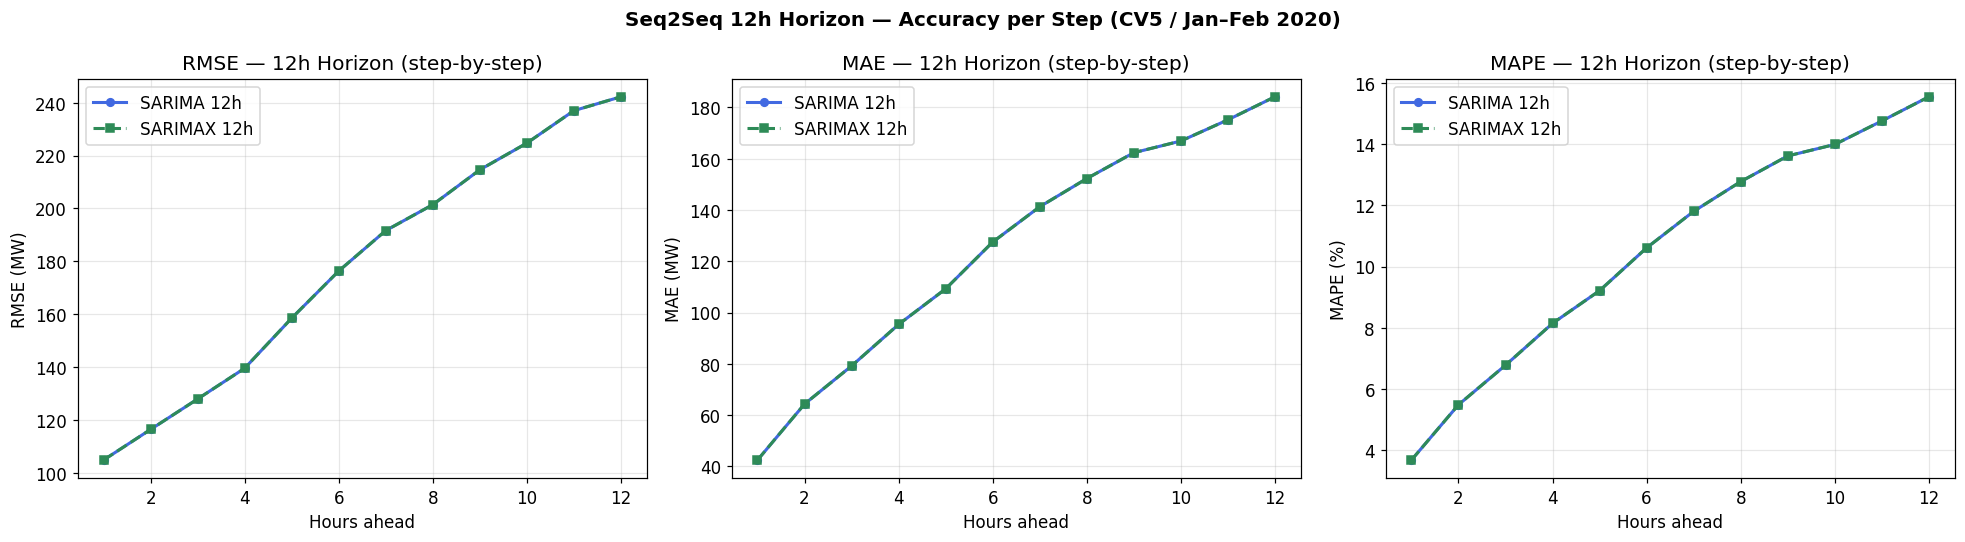

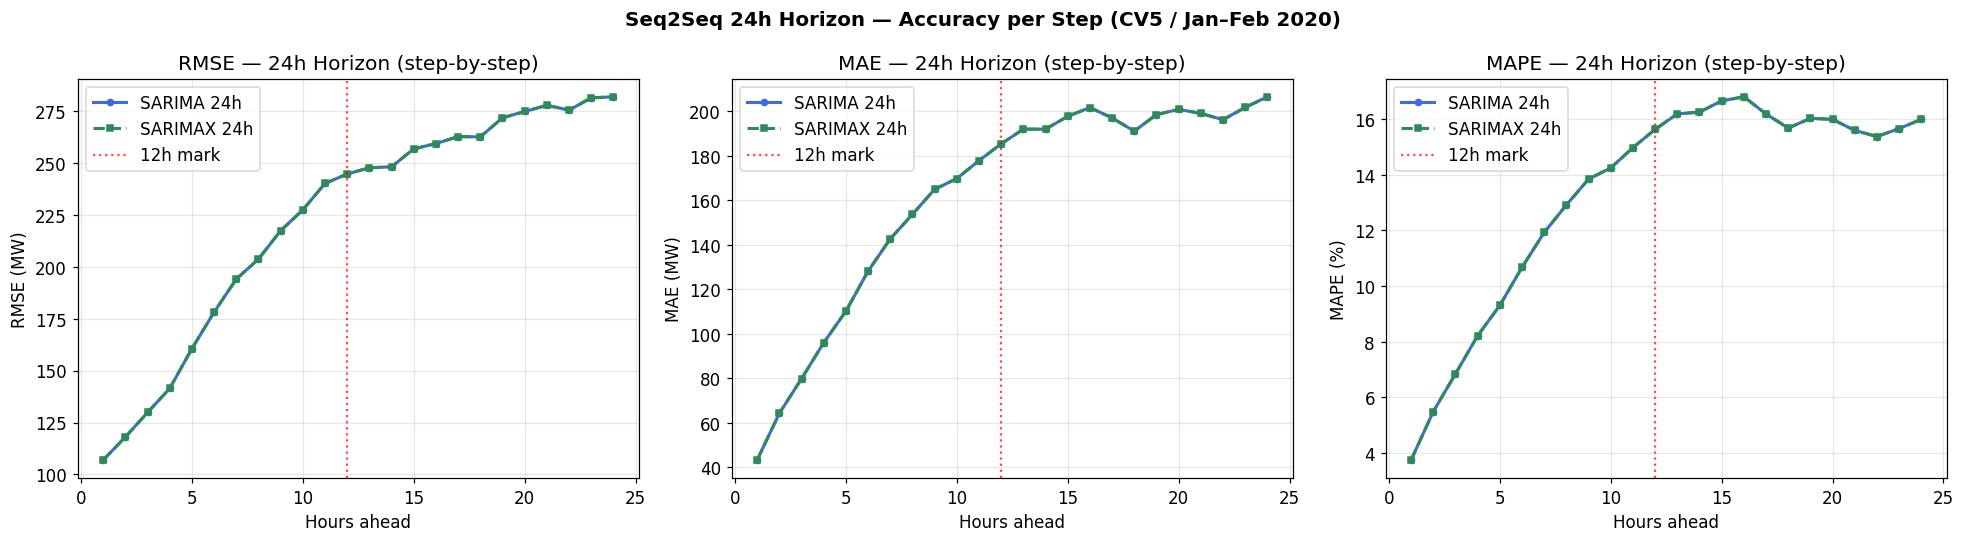


=== Aggregate: 12h vs 24h Horizon Summary ===


,Horizon,Model,Avg RMSE,Avg MAE,Avg MAPE (%),Final RMSE
0,12h,SARIMA,177.92,125.00,10.53,242.23
1,12h,SARIMAX,177.92,125.00,10.53,242.23
2,24h,SARIMA,223.50,162.09,13.34,281.96
3,24h,SARIMAX,223.50,162.09,13.34,281.96


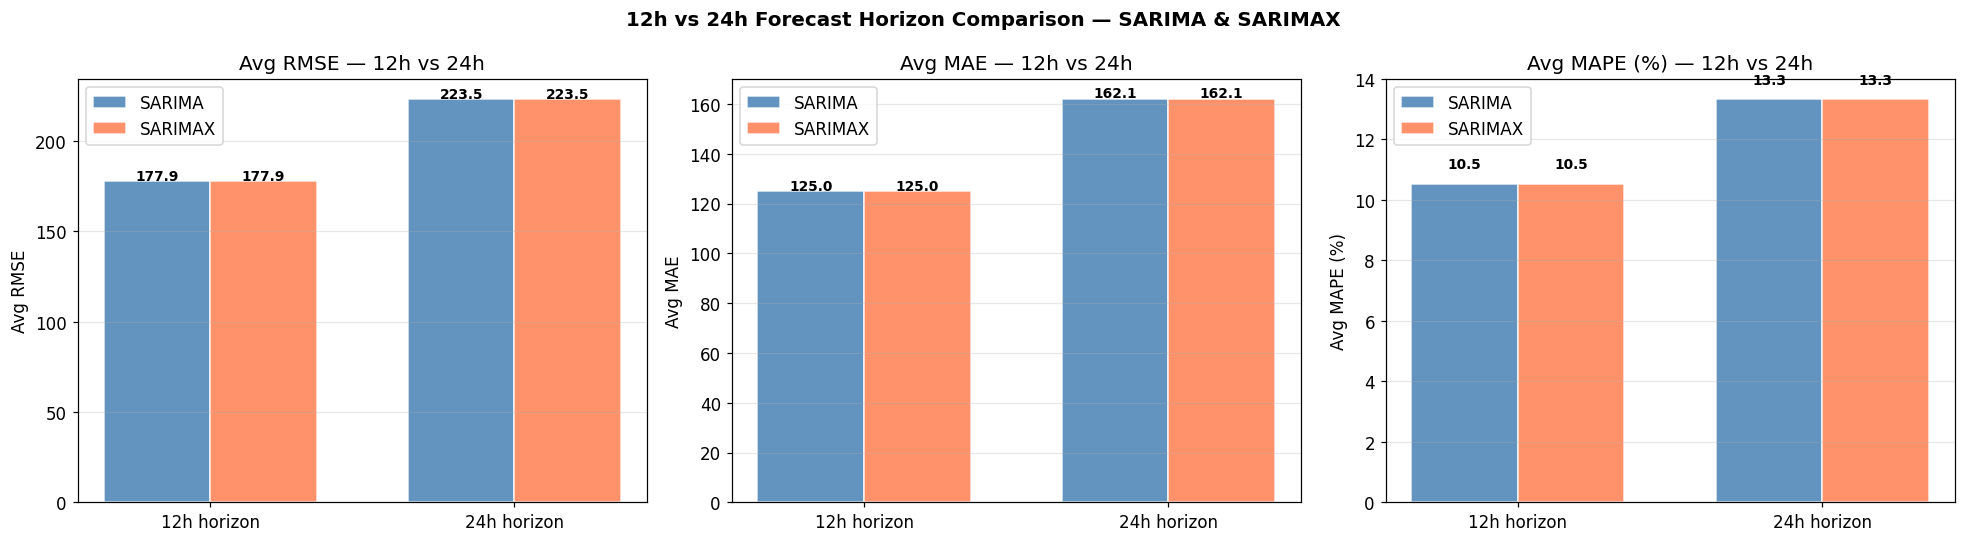


📊 Key results:
  SARIMA   12h  Avg RMSE=177.92  Avg MAPE=10.53%  Final step RMSE=242.23
  SARIMAX  12h  Avg RMSE=177.92  Avg MAPE=10.53%  Final step RMSE=242.23
  SARIMA   24h  Avg RMSE=223.50  Avg MAPE=13.34%  Final step RMSE=281.96
  SARIMAX  24h  Avg RMSE=223.50  Avg MAPE=13.34%  Final step RMSE=281.96

📌 Degradation (SARIMA):
  SARIMA  step1→step24 RMSE increase: +175.04 MW (163.7%)
  SARIMAX step1→step24 RMSE increase: +175.04 MW (163.7%)


In [26]:
# ══════════════════════════════════════════════════════════════════════════════
# Plot A: Step-by-step degradation curves — 12h horizon
# ══════════════════════════════════════════════════════════════════════════════
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
x12 = hdf_sarima_12['horizon_h'].values

for ax, metric in zip(axes, ['RMSE','MAE','MAPE']):
    ax.plot(x12, hdf_sarima_12[metric],  'o-',  color='royalblue',  lw=2, ms=5, label='SARIMA 12h')
    ax.plot(x12, hdf_sarimax_12[metric], 's--', color='seagreen',   lw=2, ms=5, label='SARIMAX 12h')
    ax.fill_between(x12, hdf_sarima_12[metric], hdf_sarimax_12[metric], alpha=0.1, color='grey')
    ax.set_xlabel('Hours ahead'); ax.set_title(f'{metric} — 12h Horizon (step-by-step)')
    ax.set_ylabel(metric + (' (%)' if metric=='MAPE' else ' (MW)'))
    ax.legend(); ax.grid(True, alpha=0.3)

plt.suptitle('Seq2Seq 12h Horizon — Accuracy per Step (CV5 / Jan–Feb 2020)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('horizon_12h_steps.png', bbox_inches='tight')
plt.show()

# ══════════════════════════════════════════════════════════════════════════════
# Plot B: Step-by-step degradation curves — 24h horizon
# ══════════════════════════════════════════════════════════════════════════════
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
x24 = hdf_sarima_24['horizon_h'].values

for ax, metric in zip(axes, ['RMSE','MAE','MAPE']):
    ax.plot(x24, hdf_sarima_24[metric],  'o-',  color='royalblue', lw=2, ms=4, label='SARIMA 24h')
    ax.plot(x24, hdf_sarimax_24[metric], 's--', color='seagreen',  lw=2, ms=4, label='SARIMAX 24h')
    ax.fill_between(x24, hdf_sarima_24[metric], hdf_sarimax_24[metric], alpha=0.1, color='grey')
    ax.axvline(12, color='red', linestyle=':', alpha=0.7, label='12h mark')
    ax.set_xlabel('Hours ahead'); ax.set_title(f'{metric} — 24h Horizon (step-by-step)')
    ax.set_ylabel(metric + (' (%)' if metric=='MAPE' else ' (MW)'))
    ax.legend(); ax.grid(True, alpha=0.3)

plt.suptitle('Seq2Seq 24h Horizon — Accuracy per Step (CV5 / Jan–Feb 2020)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('horizon_24h_steps.png', bbox_inches='tight')
plt.show()

# ══════════════════════════════════════════════════════════════════════════════
# Plot C: Aggregate comparison — 12h vs 24h (mean across steps)
# ══════════════════════════════════════════════════════════════════════════════
summary_horizon = pd.DataFrame({
    'Horizon':       ['12h', '12h', '24h', '24h'],
    'Model':         ['SARIMA','SARIMAX','SARIMA','SARIMAX'],
    'Avg RMSE':      [hdf_sarima_12.RMSE.mean(), hdf_sarimax_12.RMSE.mean(),
                      hdf_sarima_24.RMSE.mean(), hdf_sarimax_24.RMSE.mean()],
    'Avg MAE':       [hdf_sarima_12.MAE.mean(),  hdf_sarimax_12.MAE.mean(),
                      hdf_sarima_24.MAE.mean(),  hdf_sarimax_24.MAE.mean()],
    'Avg MAPE (%)':  [hdf_sarima_12.MAPE.mean(), hdf_sarimax_12.MAPE.mean(),
                      hdf_sarima_24.MAPE.mean(), hdf_sarimax_24.MAPE.mean()],
    'Final RMSE':    [hdf_sarima_12.RMSE.iloc[-1], hdf_sarimax_12.RMSE.iloc[-1],
                      hdf_sarima_24.RMSE.iloc[-1], hdf_sarimax_24.RMSE.iloc[-1]],
})

print('\n=== Aggregate: 12h vs 24h Horizon Summary ===')
display(summary_horizon.round(2))

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
x_grp   = np.arange(2)        # 12h, 24h
bar_w   = 0.35
colors  = {'SARIMA':'steelblue','SARIMAX':'coral'}

for ax, metric in zip(axes, ['Avg RMSE','Avg MAE','Avg MAPE (%)']):
    for j, mdl in enumerate(['SARIMA','SARIMAX']):
        vals = summary_horizon[summary_horizon['Model']==mdl][metric].values
        bars = ax.bar(x_grp + (j-0.5)*bar_w, vals, bar_w,
                      label=mdl, color=colors[mdl], alpha=0.85, edgecolor='white')
        for bar, v in zip(bars, vals):
            ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
                    f'{v:.1f}', ha='center', fontsize=9, fontweight='bold')
    ax.set_xticks(x_grp); ax.set_xticklabels(['12h horizon','24h horizon'])
    ax.set_title(f'{metric} — 12h vs 24h')
    ax.set_ylabel(metric); ax.legend(); ax.grid(True, alpha=0.3, axis='y')

plt.suptitle('12h vs 24h Forecast Horizon Comparison — SARIMA & SARIMAX',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('horizon_12h_vs_24h.png', bbox_inches='tight')
plt.show()

# ── Print key numbers ─────────────────────────────────────────────────────────
print('\n📊 Key results:')
for _, row in summary_horizon.iterrows():
    print(f"  {row.Model:8s} {row.Horizon}  Avg RMSE={row['Avg RMSE']:.2f}  "
          f"Avg MAPE={row['Avg MAPE (%)']:.2f}%  Final step RMSE={row['Final RMSE']:.2f}")

print('\n📌 Degradation (SARIMA):')
deg = hdf_sarima_24.RMSE.iloc[-1] - hdf_sarima_24.RMSE.iloc[0]
pct = deg / hdf_sarima_24.RMSE.iloc[0] * 100
print(f'  SARIMA  step1→step24 RMSE increase: +{deg:.2f} MW ({pct:.1f}%)')
deg = hdf_sarimax_24.RMSE.iloc[-1] - hdf_sarimax_24.RMSE.iloc[0]
pct = deg / hdf_sarimax_24.RMSE.iloc[0] * 100
print(f'  SARIMAX step1→step24 RMSE increase: +{deg:.2f} MW ({pct:.1f}%)')

## Step 10: Exogenous Variable Analysis — All Folds

In [27]:
exog_results = []
MAX_TR_EX = 800   # raise to 1500 for more accurate comparison

for fold_name, sp in cv_splits.items():
    tr    = sp['train']['nat_demand'].values[-MAX_TR_EX:]
    va    = sp['val']['nat_demand'].values[:200]
    tr_ex = sp['train'][EXOG_COLS].values[-MAX_TR_EX:]
    va_ex = sp['val'][EXOG_COLS].values[:200]

    try:
        m1   = SARIMAX(tr, order=(best_p,best_d,best_q),
                       seasonal_order=(best_sp,best_sd,best_sq,best_s),
                       enforce_stationarity=False, enforce_invertibility=False).fit(disp=False)
        fc1  = m1.forecast(len(va))
        m2   = SARIMAX(tr, exog=tr_ex, order=(best_p,best_d,best_q),
                       seasonal_order=(best_sp,best_sd,best_sq,best_s),
                       enforce_stationarity=False, enforce_invertibility=False).fit(disp=False)
        fc2  = m2.forecast(len(va), exog=va_ex)
        exog_results.append({'Fold': fold_name,
            'SARIMA_RMSE': rmse(va,fc1), 'SARIMA_MAE': mae(va,fc1), 'SARIMA_MAPE': mape(va,fc1),
            'SARIMAX_RMSE':rmse(va,fc2), 'SARIMAX_MAE':mae(va,fc2), 'SARIMAX_MAPE':mape(va,fc2)})
        print(f'{fold_name}  SARIMA RMSE={rmse(va,fc1):.2f}  SARIMAX RMSE={rmse(va,fc2):.2f} ✅')
    except Exception as e:
        print(f'{fold_name} ❌ {e}')

exog_df = pd.DataFrame(exog_results)
print('\n=== SARIMA vs SARIMAX — All Folds ===')
display(exog_df)

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


CV1  SARIMA RMSE=159.61  SARIMAX RMSE=159.04 ✅


/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


CV2  SARIMA RMSE=149.04  SARIMAX RMSE=150.42 ✅


/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


CV3  SARIMA RMSE=110.08  SARIMAX RMSE=116.87 ✅


/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


CV4  SARIMA RMSE=130.99  SARIMAX RMSE=116.40 ✅
CV5  SARIMA RMSE=137.94  SARIMAX RMSE=136.94 ✅

=== SARIMA vs SARIMAX — All Folds ===


,Fold,SARIMA_RMSE,SARIMA_MAE,SARIMA_MAPE,SARIMAX_RMSE,SARIMAX_MAE,SARIMAX_MAPE
0,CV1,159.607258,121.166871,11.504533,159.038008,118.825670,11.279795
1,CV2,149.042468,105.262235,10.131272,150.420790,105.207757,10.239619
2,CV3,110.077216,88.709142,8.071779,116.873373,94.981321,8.585502
3,CV4,130.989990,112.491404,9.303807,116.396699,94.254193,7.831535
4,CV5,137.943809,113.075917,9.366003,136.940570,112.392841,9.319624


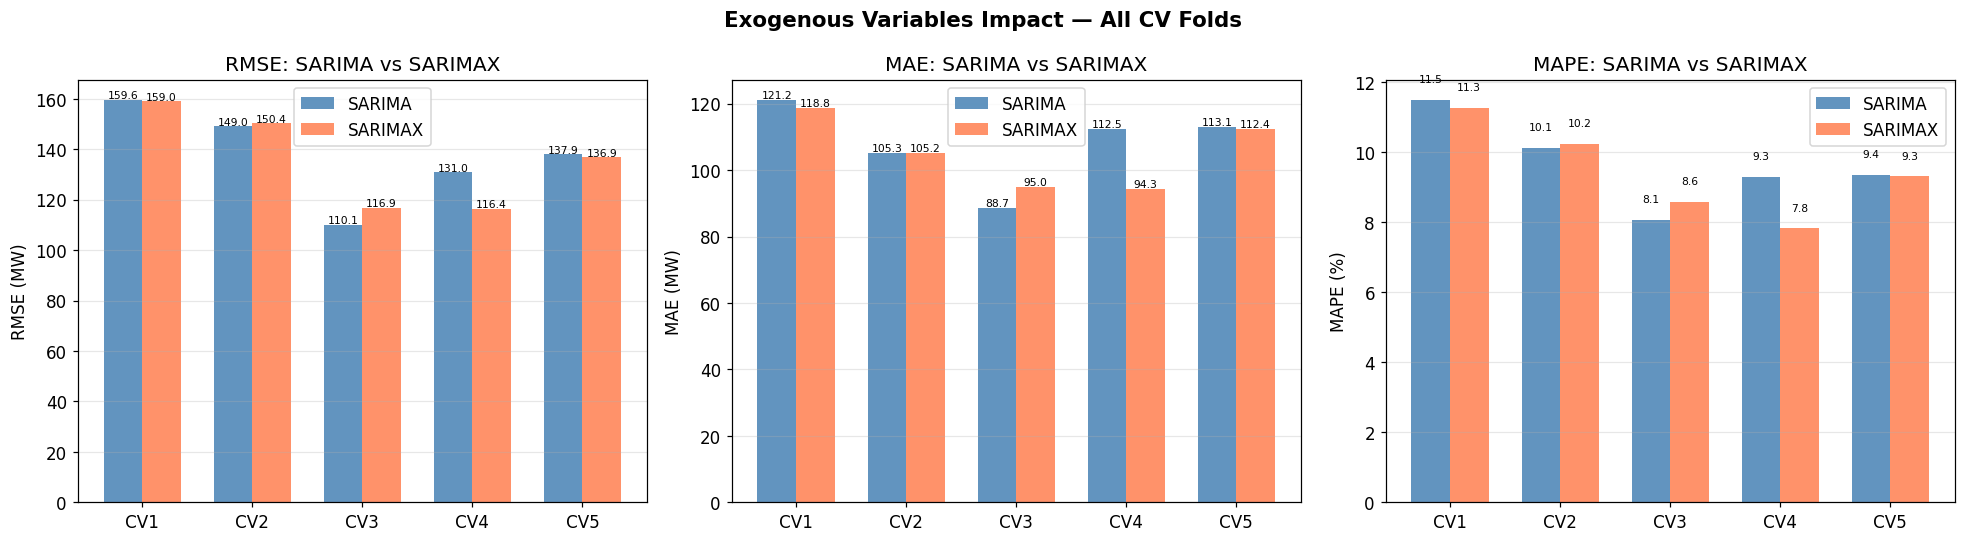

In [40]:
# ── Grouped bar chart ─────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
x, w = np.arange(len(exog_df)), 0.35

for ax, metric, unit in zip(axes, ['RMSE','MAE','MAPE'], ['MW','MW','%']):
    b1 = ax.bar(x-w/2, exog_df[f'SARIMA_{metric}'],  w, label='SARIMA',  color='steelblue', alpha=0.85)
    b2 = ax.bar(x+w/2, exog_df[f'SARIMAX_{metric}'], w, label='SARIMAX', color='coral', alpha=0.85)
    ax.set_xticks(x); ax.set_xticklabels(exog_df['Fold'])
    ax.set_ylabel(f'{metric} ({unit})'); ax.set_title(f'{metric}: SARIMA vs SARIMAX')
    ax.legend(); ax.grid(True, alpha=0.3, axis='y')
    for bar in list(b1)+list(b2):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
                f'{bar.get_height():.1f}', ha='center', fontsize=7)

plt.suptitle('Exogenous Variables Impact — All CV Folds', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('exog_comparison.png', bbox_inches='tight')
plt.show()

## Step 11: Robustness + Wilcoxon Signed-Rank Test

=== Wilcoxon Signed-Rank Test ===
H₀: No difference in RMSE between SARIMA and SARIMAX
SARIMA  RMSEs : [159.61 149.04 110.08 130.99 137.94]
SARIMAX RMSEs : [159.04 150.42 116.87 116.4  136.94]
Δ RMSE        : [ 0.57 -1.38 -6.8  14.59  1.  ]

Wilcoxon W : 7.0
p-value    : 1.0000
Result     : ⚠️  No significant difference (p ≥ 0.05) — 5 folds may be insufficient for full power


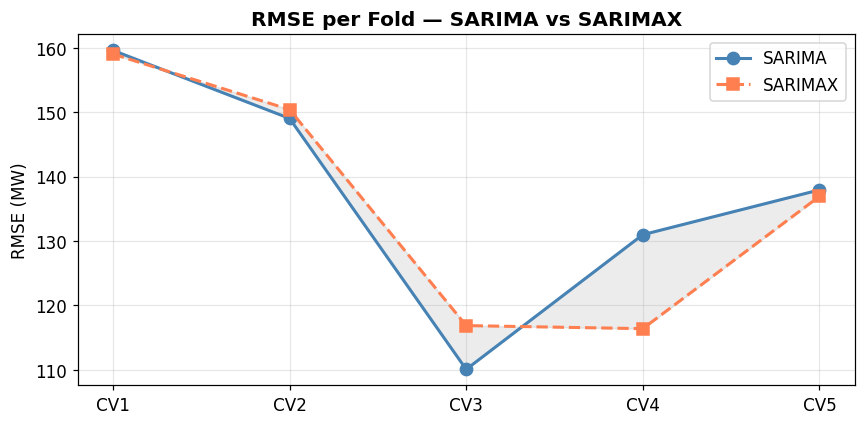

In [28]:
sarima_rmses  = exog_df['SARIMA_RMSE'].values
sarimax_rmses = exog_df['SARIMAX_RMSE'].values

print('=== Wilcoxon Signed-Rank Test ===')
print(f'H₀: No difference in RMSE between SARIMA and SARIMAX')
print(f'SARIMA  RMSEs : {np.round(sarima_rmses,2)}')
print(f'SARIMAX RMSEs : {np.round(sarimax_rmses,2)}')
print(f'Δ RMSE        : {np.round(sarima_rmses - sarimax_rmses, 2)}')

try:
    stat, p = wilcoxon(sarima_rmses, sarimax_rmses)
    print(f'\nWilcoxon W : {stat}')
    print(f'p-value    : {p:.4f}')
    verdict = ('✅ Exogenous variables significantly improve accuracy (p < 0.05)'
               if p < 0.05 else
               '⚠️  No significant difference (p ≥ 0.05) — 5 folds may be insufficient for full power')
    print(f'Result     : {verdict}')
except Exception as e:
    print(f'Note: {e}')

# ── Visual ───────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(exog_df['Fold'], sarima_rmses,  'o-', color='steelblue', label='SARIMA',  linewidth=2, markersize=8)
ax.plot(exog_df['Fold'], sarimax_rmses, 's--', color='coral',    label='SARIMAX', linewidth=2, markersize=8)
ax.fill_between(exog_df['Fold'], sarima_rmses, sarimax_rmses, alpha=0.15, color='grey')
ax.set_title('RMSE per Fold — SARIMA vs SARIMAX', fontweight='bold')
ax.set_ylabel('RMSE (MW)'); ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('wilcoxon_plot.png', bbox_inches='tight')
plt.show()

## Step 12: Overfitting Analysis — Train vs Validation Behaviour

Comparing in-sample (training) error vs out-of-sample (validation) error per fold.
A large gap indicates overfitting; a stable gap indicates good generalisation.


In [29]:
overfit_rows = []

for fold_name, data in stored.items():
    fc_d = data['fc']
    tr_d = data['tr']
    tr_s = data['train_series']
    va_s = fc_d['actual']

    for model_key in ['ARIMA','SARIMA','SARIMAX']:
        if model_key in fc_d and model_key in tr_d:
            tr_fit = tr_d[model_key]
            # align: fitted values may be shorter than training series
            n = min(len(tr_s), len(tr_fit))
            tr_actual = tr_s[-n:]
            tr_pred   = np.array(tr_fit)[-n:]
            mask = ~np.isnan(tr_pred)
            if mask.sum() > 10:
                tr_rmse = rmse(tr_actual[mask], tr_pred[mask])
                va_rmse = rmse(va_s, fc_d[model_key])
                overfit_rows.append({
                    'Fold': fold_name, 'Model': model_key,
                    'Train_RMSE': tr_rmse, 'Val_RMSE': va_rmse,
                    'Gap': va_rmse - tr_rmse,
                    'Gap_pct': (va_rmse - tr_rmse) / tr_rmse * 100
                })

overfit_df = pd.DataFrame(overfit_rows)
print('=== Train vs Validation RMSE ===')
display(overfit_df.round(2))

=== Train vs Validation RMSE ===


,Fold,Model,Train_RMSE,Val_RMSE,Gap,Gap_pct
0,CV1,ARIMA,57.37,204.12,146.74,255.76
1,CV1,SARIMA,41.83,178.34,136.51,326.36
2,CV1,SARIMAX,31.89,187.43,155.54,487.71
3,CV2,ARIMA,51.59,185.67,134.08,259.89
4,CV2,SARIMA,38.43,129.49,91.06,236.96
5,CV2,SARIMAX,32.84,123.60,90.76,276.39
6,CV3,ARIMA,56.61,173.67,117.06,206.78
7,CV3,SARIMA,43.02,129.82,86.80,201.76
8,CV3,SARIMAX,37.33,122.72,85.40,228.77
9,CV4,ARIMA,58.46,205.19,146.73,250.99


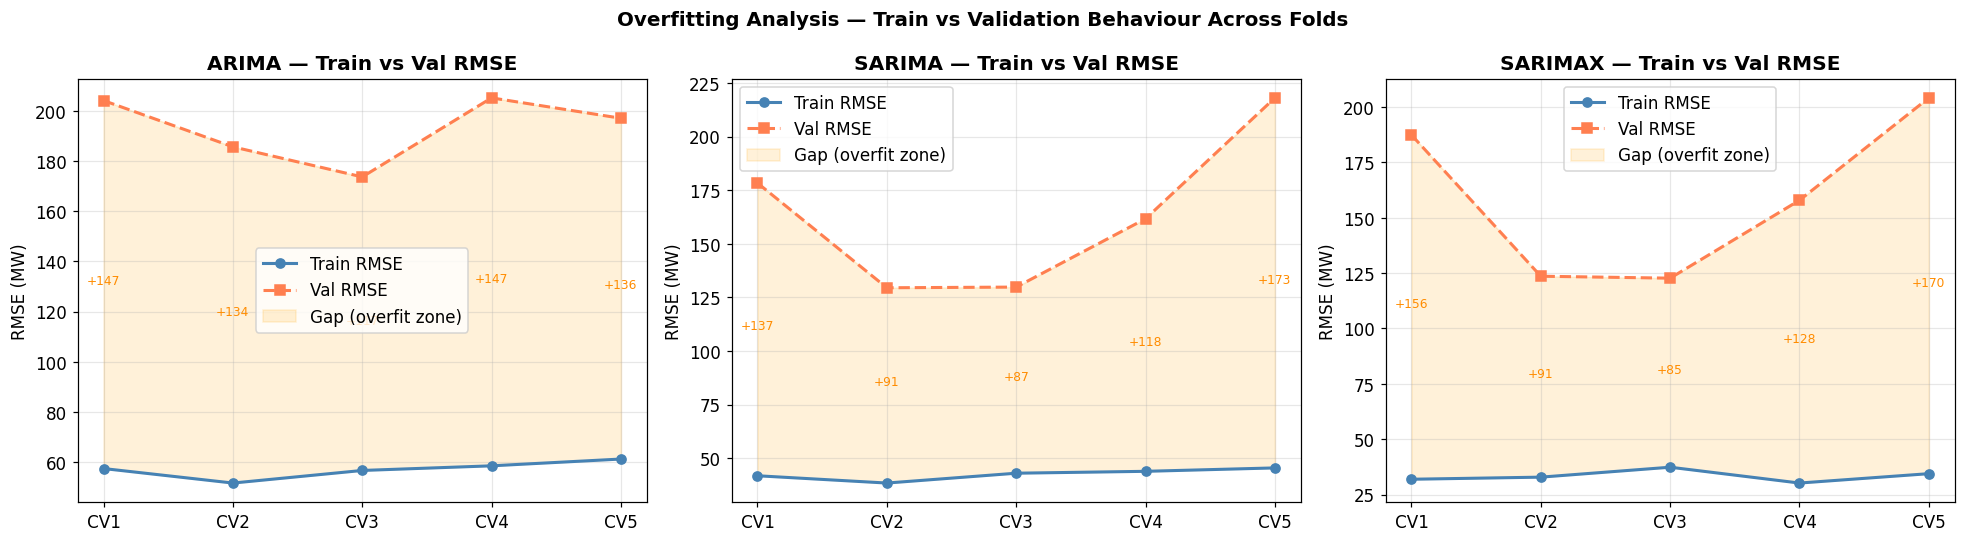


📌 Interpretation:
  • Small stable gap → good generalisation
  • Growing gap across folds → distribution shift over years
  • Val RMSE < Train RMSE → unlikely (check for data leakage)


In [30]:
# ── Train vs Val RMSE per model ──────────────────────────────────────────────
models_present = overfit_df['Model'].unique()
fig, axes = plt.subplots(1, len(models_present), figsize=(6*len(models_present), 5), sharey=False)
if len(models_present) == 1: axes = [axes]

for ax, mdl in zip(axes, models_present):
    sub = overfit_df[overfit_df['Model'] == mdl]
    ax.plot(sub['Fold'], sub['Train_RMSE'], 'o-', color='steelblue', label='Train RMSE', linewidth=2)
    ax.plot(sub['Fold'], sub['Val_RMSE'],   's--', color='coral',    label='Val RMSE',   linewidth=2)
    ax.fill_between(sub['Fold'], sub['Train_RMSE'], sub['Val_RMSE'],
                    alpha=0.15, color='orange', label='Gap (overfit zone)')
    ax.set_title(f'{mdl} — Train vs Val RMSE', fontweight='bold')
    ax.set_ylabel('RMSE (MW)'); ax.legend(); ax.grid(True, alpha=0.3)
    # annotate gap
    for _, row in sub.iterrows():
        ax.annotate(f'+{row.Gap:.0f}', xy=(row.Fold, (row.Train_RMSE+row.Val_RMSE)/2),
                    ha='center', fontsize=8, color='darkorange')

plt.suptitle('Overfitting Analysis — Train vs Validation Behaviour Across Folds',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('overfitting_analysis.png', bbox_inches='tight')
plt.show()

print('\n📌 Interpretation:')
print('  • Small stable gap → good generalisation')
print('  • Growing gap across folds → distribution shift over years')
print('  • Val RMSE < Train RMSE → unlikely (check for data leakage)')

## Step 13: Error Analysis + Feature Importance (SHAP)

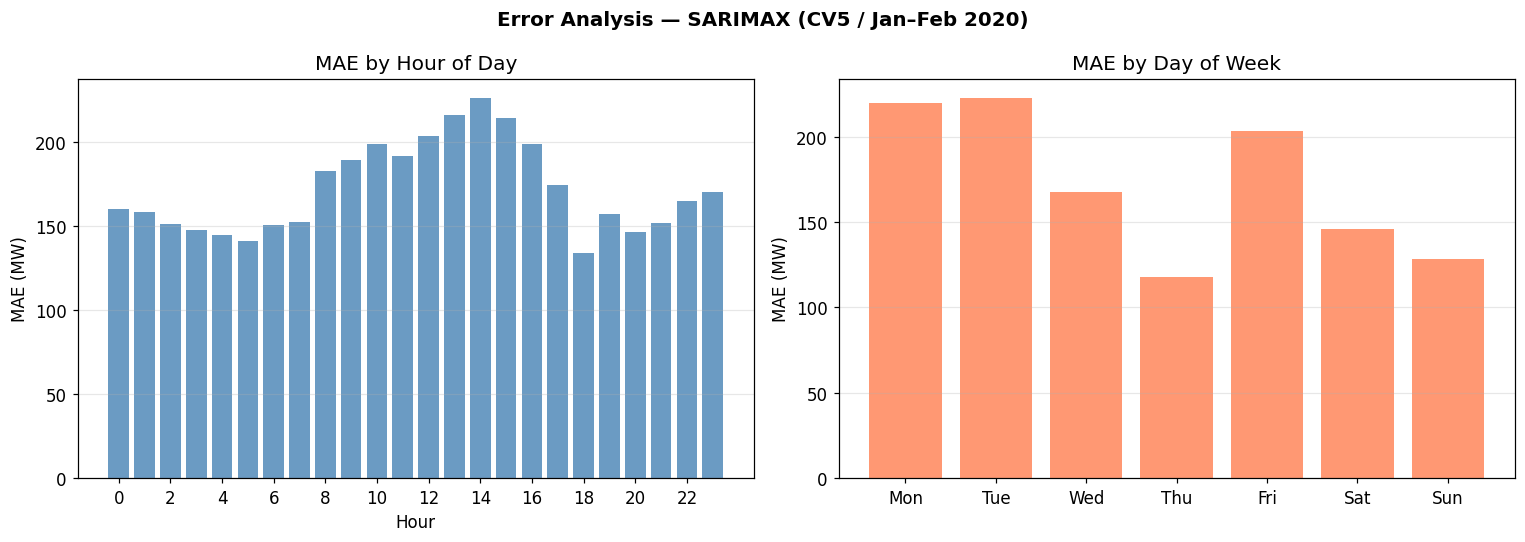

In [31]:
# ── Error by hour and weekday (CV5 val) ──────────────────────────────────────
cv5_val_df = cv_splits['CV5']['val'].copy().reset_index(drop=True)
best_fc_key = 'SARIMAX' if 'SARIMAX' in stored['CV5']['fc'] else 'SARIMA'
n = min(len(cv5_val_df), len(stored['CV5']['fc'][best_fc_key]))
cv5_val_df = cv5_val_df.iloc[:n].copy()
cv5_val_df['predicted'] = stored['CV5']['fc'][best_fc_key][:n]
cv5_val_df['abs_error'] = np.abs(cv5_val_df['nat_demand'] - cv5_val_df['predicted'])
cv5_val_df['pct_error'] = cv5_val_df['abs_error'] / cv5_val_df['nat_demand'] * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

err_hour = cv5_val_df.groupby('hour')['abs_error'].mean()
axes[0].bar(err_hour.index, err_hour.values, color='steelblue', alpha=0.8)
axes[0].set_title('MAE by Hour of Day'); axes[0].set_xlabel('Hour')
axes[0].set_ylabel('MAE (MW)'); axes[0].grid(True, alpha=0.3, axis='y')
axes[0].set_xticks(range(0,24,2))

day_names = ['Mon','Tue','Wed','Thu','Fri','Sat','Sun']
err_dow = cv5_val_df.groupby('dayofweek')['abs_error'].mean()
axes[1].bar([day_names[d] for d in err_dow.index], err_dow.values, color='coral', alpha=0.8)
axes[1].set_title('MAE by Day of Week'); axes[1].set_ylabel('MAE (MW)')
axes[1].grid(True, alpha=0.3, axis='y')

plt.suptitle(f'Error Analysis — {best_fc_key} (CV5 / Jan–Feb 2020)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('error_analysis.png', bbox_inches='tight')
plt.show()

Random Forest (CV4 val):
RandomForest                                                       RMSE=33.33  MAE=19.11  MAPE=1.74%


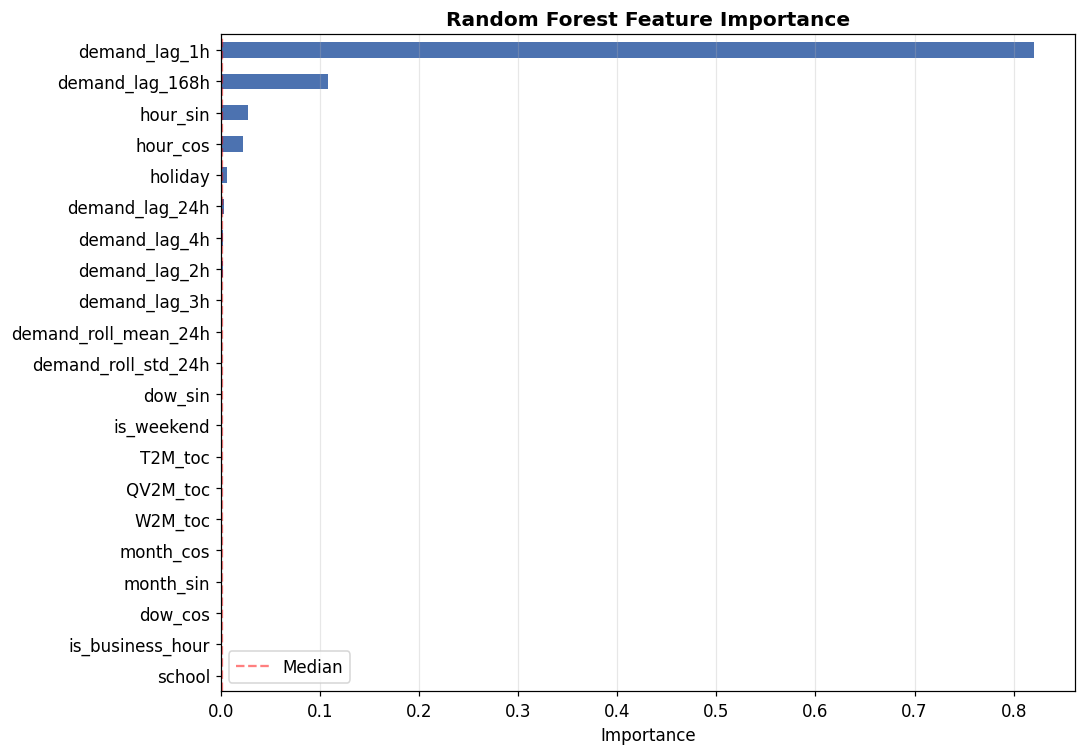

In [46]:
# ── Random Forest feature importance ─────────────────────────────────────────
feature_cols = [
    'hour_sin','hour_cos','dow_sin','dow_cos','month_sin','month_cos',
    'is_weekend','is_business_hour','holiday','school',
    'T2M_toc','W2M_toc','QV2M_toc',
    'demand_lag_1h','demand_lag_2h','demand_lag_3h','demand_lag_4h',
    'demand_lag_24h','demand_lag_168h',
    'demand_roll_mean_24h','demand_roll_std_24h'
]

# Use CV4 (largest labelled train set before final test)
train_d = cv_splits['CV4']['train'].dropna(subset=feature_cols+['nat_demand'])
val_d   = cv_splits['CV4']['val'].dropna(subset=feature_cols+['nat_demand'])

rf = RandomForestRegressor(n_estimators=200, max_depth=12, random_state=SEED, n_jobs=-1)
rf.fit(train_d[feature_cols], train_d['nat_demand'])
rf_preds = rf.predict(val_d[feature_cols])

print('Random Forest (CV4 val):')
evaluate(val_d['nat_demand'].values, rf_preds, 'RandomForest')

fi = pd.Series(rf.feature_importances_, index=feature_cols).sort_values(ascending=True)
fig, ax = plt.subplots(figsize=(10, 7))
colors_fi = ['#4C72B0' if v > fi.median() else '#AECDE8' for v in fi.values]
fi.plot.barh(ax=ax, color=colors_fi)
ax.set_title('Random Forest Feature Importance', fontweight='bold')
ax.set_xlabel('Importance')
ax.axvline(fi.median(), color='red', linestyle='--', alpha=0.5, label='Median')
ax.legend(); ax.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.savefig('feature_importance.png', bbox_inches='tight')
plt.show()

In [44]:
print(cv_splits['CV4']['train'].columns)
print('demand_lag_4h' in cv_splits['CV4']['train'].columns)

Index(['datetime', 'nat_demand', 'T2M_toc', 'QV2M_toc', 'TQL_toc', 'W2M_toc',
       'T2M_san', 'QV2M_san', 'TQL_san', 'W2M_san', 'T2M_dav', 'QV2M_dav',
       'TQL_dav', 'W2M_dav', 'Holiday_ID', 'holiday', 'school', 'hour',
       'dayofweek', 'month', 'year', 'dayofyear', 'quarter', 'is_weekend',
       'is_business_hour', 'hour_sin', 'hour_cos', 'dow_sin', 'dow_cos',
       'month_sin', 'month_cos', 'demand_lag_1h', 'demand_lag_2h',
       'demand_lag_3h', 'demand_lag_6h', 'demand_lag_12h', 'demand_lag_24h',
       'demand_lag_48h', 'demand_lag_168h', 'demand_roll_mean_6h',
       'demand_roll_std_6h', 'demand_roll_mean_12h', 'demand_roll_std_12h',
       'demand_roll_mean_24h', 'demand_roll_std_24h', 'demand_roll_mean_168h',
       'demand_roll_std_168h', 'demand_diff_1h', 'demand_diff_24h'],
      dtype='object')
False


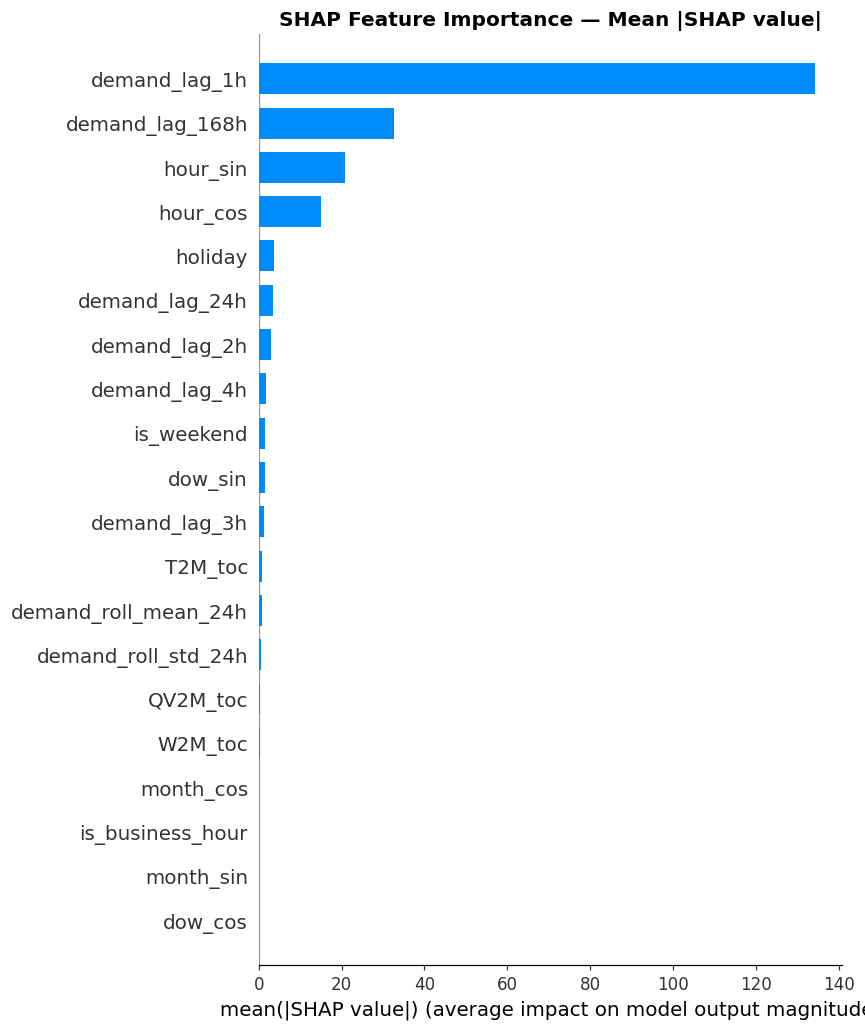

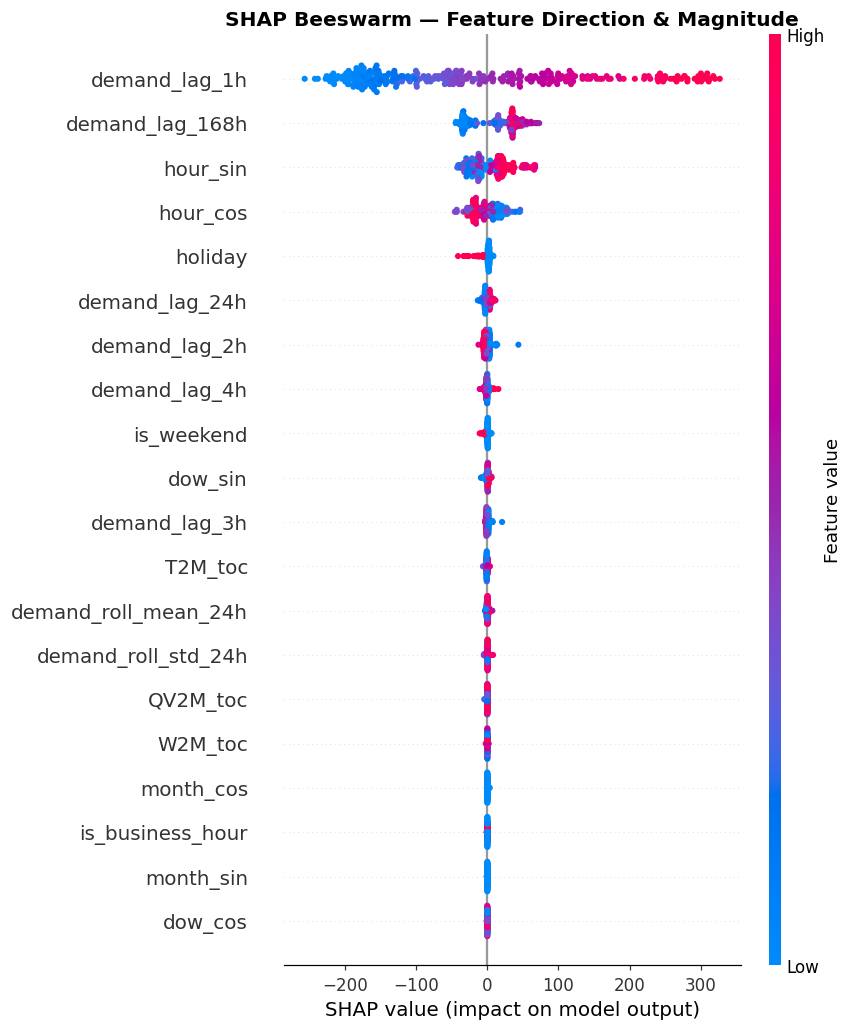

In [47]:
# ── SHAP values ───────────────────────────────────────────────────────────────
explainer   = shap.TreeExplainer(rf)
shap_sample = val_d[feature_cols].iloc[:300]
shap_values = explainer.shap_values(shap_sample)

# Bar summary
plt.figure(figsize=(10, 7))
shap.summary_plot(shap_values, shap_sample, plot_type='bar', show=False)
plt.title('SHAP Feature Importance — Mean |SHAP value|', fontweight='bold')
plt.tight_layout()
plt.savefig('shap_bar.png', bbox_inches='tight')
plt.show()

# Beeswarm
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, shap_sample, show=False)
plt.title('SHAP Beeswarm — Feature Direction & Magnitude', fontweight='bold')
plt.tight_layout()
plt.savefig('shap_beeswarm.png', bbox_inches='tight')
plt.show()

## 💾 Save All Plots to Google Drive (Optional)

In [ ]:
# Uncomment to save all output plots to Google Drive
# from google.colab import drive
# drive.mount('/content/drive', force_remount=True)

# import shutil, os
# SAVE_DIR = '/content/drive/MyDrive/electricity_forecast_outputs'
# os.makedirs(SAVE_DIR, exist_ok=True)

# ALL_PLOTS = [
#     'eda_overview.png', 'eda_seasonality.png', 'eda_distribution.png', 'eda_acf_pacf.png',
#     'cv_splits_year.png', 'grid_search.png',
#     'eval_per_fold.png', 'eval_mae_mape.png', 'forecast_cv5.png', 'residuals_cv5.png',
#     'horizon_12h_steps.png', 'horizon_24h_steps.png', 'horizon_12h_vs_24h.png',
#     'exog_comparison.png', 'wilcoxon_plot.png',
#     'overfitting_analysis.png', 'error_analysis.png',
#     'feature_importance.png', 'shap_bar.png', 'shap_beeswarm.png',
# ]
# for f in ALL_PLOTS:
#     if os.path.exists(f):
#         shutil.copy(f, SAVE_DIR); print(f'✅ {f}')
#     else:
#         print(f'⚠️  Not found: {f}')

print('Uncomment the block above to save all plots to Drive.')

## 📊 Final Summary

### Forecasting goal recap
| | |
|---|---|
| **Primary** | 12-hour ahead seq2seq (12 steps at once), 24 h history |
| **Secondary** | 24-hour ahead seq2seq (24 steps at once), 24 h history |
| **Comparison** | 12h vs 24h: accuracy degradation across the full daily cycle |
| **CV** | 5-fold year-based expanding window (walk-forward) |

---
### Cross-fold model results — fill in after Step 8

| Model | Avg RMSE | Avg MAE | Avg MAPE (%) | Folds |
|---|---|---|---|---|
| ARIMA(2,1,2) | | | | CV1–CV5 |
| SARIMA (best from grid) | | | | CV1–CV5 |
| SARIMAX (best + exog) | | | | CV1–CV5 |
| Random Forest (all features) | | | | CV4 val |

---
### Horizon comparison — fill in after Step 9

| Model | Horizon | Avg RMSE | Avg MAPE | Step-1 RMSE | Final-step RMSE |
|---|---|---|---|---|---|
| SARIMA | 12h | | | | |
| SARIMAX | 12h | | | | |
| SARIMA | 24h | | | | |
| SARIMAX | 24h | | | | |

---
### Model justification summary
- **ARIMA** — trend/autocorrelation baseline; ignores daily seasonality → expected highest error
- **SARIMA** — adds s=24 seasonal structure → captures dominant daily cycle
- **SARIMAX** — adds weather + calendar exogenous → tests whether external drivers reduce residual error

---
> **Next step:** Replace SARIMA/SARIMAX with deep learning (LSTM / GRU / TCN / Seq2Seq Transformer)
> using the **same 5-fold year-based CV splits** and **same 12h / 24h horizon evaluation**.
> Switch Colab to **GPU** runtime before training deep learning models.
